# 6 — Métodos lineales para clasificación: LDA, QDA y regresión logística

📓 [Notebook de clase](../raw/6_metodos_lineales_clasificacion.ipynb) · ✏️ [Ejercicios](../exercises/6_metodos_lineales_clasificacion.ipynb) · 📕 *ESL* (Hastie, Tibshirani & Friedman) cap. 4 como referencia principal · 📒 [Notebook del cap. 4 de ESL](../../../books/explained/cap4_metodos_lineales_clasificacion.ipynb) para ir más hondo

> **TL;DR**
>
> - Un clasificador es **lineal** cuando las fronteras entre las regiones que asigna a cada clase son **hiperplanos** en el espacio de las $x$. La clase vio tres maneras de llegar a eso: regresión lineal sobre indicadoras, LDA y regresión logística.
> - Regresión lineal sobre indicadoras funciona, pero sus salidas no son probabilidades y, con 3 o más clases, puede **tapar** una clase entera (*masking*): para clasificar solo importa el **orden** de los $\hat f_k(x)$, y la recta lo puede invertir.
> - **LDA** sale de Bayes suponiendo que cada clase es una normal multivariada **con la misma covarianza** $\mathbf{\Sigma}$. Ese supuesto hace que el término cuadrático en $x$ se cancele y el log-cociente de posteriores quede **lineal**. Si cada clase tiene su $\mathbf{\Sigma}_k$, no se cancela y sale **QDA**, con fronteras cuadráticas.
> - Con la descomposición $\hat{\mathbf{\Sigma}} = \mathbf{U}\mathbf{D}\mathbf{U}^T$ se puede **esferizar** (girar y escalar hasta que las nubes queden redondas), y LDA pasa a ser "el centroide más cercano", corregido por el prior. Descomponer no es más rápido que invertir: lo que se gana es estabilidad numérica y una lectura geométrica (Mahalanobis cuenta desvíos; $|\hat{\mathbf{\Sigma}}_k|$ mide el volumen de la nube).
> - **Regresión logística** modela directamente que el **log-odds** es lineal en $x$. No tiene solución cerrada: se maximiza la log-verosimilitud con **Newton-Raphson**, que reescrito resulta ser una sucesión de cuadrados mínimos ponderados (**IRLS**).
> - LDA y logística producen fronteras con **la misma forma** ($\beta_0 + \beta^T x = 0$). Lo que cambia es cómo estiman los coeficientes: LDA usa todo el modelo de cómo se generan las $x$; la logística solo modela $P(G \mid X)$.

## 🗺️ Mapa de la clase

| Bloque de la clase | Celdas | Dónde lo explico |
|--------------------|--------|------------------|
| Métodos Lineales para Clasificación › Bibliografía: | 0 | §1 |
| Métodos Lineales para Clasificación | 1–4 | §1 |
| Análisis Discriminante Lineal (LDA) | 5–14 | §2 (celdas 5–7), §3 (celdas 8–13), §4 (celda 14) |
| Análisis Discriminante Cuadrático (QDA) | 15 | §4 |
| Análisis Discriminante | 16–18 | §5 |
| Análisis Discriminante Lineal (LDA) › Reducción de Dimensionalidad con LDA | 19 | §5 |
| Intermezzo: Newton-Raphson | 20–23 | §6 |
| Intermezzo: Distribución multinomial | 24 | §8 |
| Regresión Logística | 25–28 | §7 |
| Regresión Logística › Entrenamiento | 29–36 | §8 (celdas 29–32), §9 (celdas 33–36) |
| Regresión Logística › Regularización | 37 | §10 |
| Ejercicios | 38 | 🎯 Centros |

Las secciones:

1. Qué hace lineal a un clasificador, y regresión sobre indicadoras
2. De Bayes a LDA: los ingredientes
3. La frontera de LDA es un hiperplano
4. Estimar los parámetros, y QDA
5. Esferizar: LDA como centroide más cercano
6. Intermezzo: Newton-Raphson
7. Regresión logística: el modelo
8. Máxima verosimilitud y el gradiente
9. Newton aplicado a la logística: Hessiano e IRLS
10. Regresión logística regularizada

In [1]:
# Setup
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})
np.set_printoptions(precision=4, suppress=True)
colores = sns.color_palette("colorblind")

## 1. Qué hace *lineal* a un clasificador, y regresión sobre indicadoras

📓 celdas 0–4 · 📕 ESL §4.1, §4.2

### La idea en criollo

Hasta la clase 5 la salida era un número: precio, puntaje, nivel de PSA. Ahora la salida es una **etiqueta**: "spam o no spam", "clase 1, 2 o 3". Un clasificador no predice un número, **reparte el espacio** de las $x$ en regiones y le pone una etiqueta a cada una.

Pensalo como un mapa político dibujado con regla: cada provincia es la región de una clase, y todas las fronteras entre provincias son tramos de recta. Un clasificador lineal es eso. Con dos variables las fronteras son rectas, con tres son planos, y con $p$ variables son **hiperplanos** (el análogo de un plano en $p$ dimensiones: todo lo que cumple una única ecuación lineal).

> **Dónde se rompe la analogía.** En un mapa las fronteras se dibujan primero y las provincias salen de ahí. Acá es al revés: cada método calcula, para cada $x$, un **puntaje** por clase, y la frontera aparece sola donde dos puntajes empatan. Y "lineal" habla de la frontera en el espacio donde vos ponés las variables: si agregás $x_1^2$ como variable nueva, la frontera sigue siendo un hiperplano en el espacio ampliado, pero vista en el plano $(x_1, x_2)$ original es una curva.

### Formalizándolo

**La notación (ESL §2.2).** La salida categórica se llama $G$ (de *group*). Toma valores en el conjunto de etiquetas $\mathcal{G} = \{1, 2, \ldots, K\}$, donde $K$ es la cantidad de clases. El clasificador es una función $\hat G(x)$ (leelo "ge sombrero de equis") que a cada vector de entrada $x \in \mathbb{R}^p$ le asigna una etiqueta de $\mathcal{G}$. La región de la clase $k$ es el conjunto de puntos a los que el clasificador les dice $k$:

$$\mathcal{R}_k = \{x : \hat G(x) = k\}.$$

Un método es **lineal** cuando la frontera entre dos regiones vecinas es un conjunto de la forma

$$\{x : \beta_0 + \beta^T x = 0\},$$

con $\beta_0$ un número (el intercepto) y $\beta \in \mathbb{R}^p$ un vector. Eso es un hiperplano.

**El caso binario con regresión (celda 2).** Codificás la etiqueta como $y_i \in \{0, 1\}$, ajustás una regresión lineal por cuadrados mínimos, como en la clase 2, y clasificás según si la predicción supera un umbral:

$$\hat G(x) = \begin{cases} 1 & \text{si } \hat\beta_0 + \hat\beta^T x > 0.5 \\ 0 & \text{si no} \end{cases}$$

La frontera es $\hat\beta_0 + \hat\beta^T x = 0.5$, que se reescribe como $(\hat\beta_0 - 0.5) + \hat\beta^T x = 0$: un hiperplano. El método es lineal.

La clase marca dos problemas:

1. **Predice fuera de $[0, 1]$.** La recta no tiene techo ni piso: lejos de los datos se va a $\pm\infty$. Si querías leer $\hat y$ como una probabilidad, no podés.
2. **Es sensible a puntos atípicos.** Cuadrados mínimos castiga el residuo al cuadrado, en las dos direcciones. Un punto de la clase 1 que está muy lejos, del lado "correcto", tiene una predicción de, digamos, $3$, y el residuo $1 - 3 = -2$ pesa $4$ en el $RSS$. La recta se inclina para acercarse a él, y la frontera se corre aunque ese punto estaba **bien clasificado**. Es castigar a alguien por tener *demasiada* razón.

**El caso multiclase (celda 3).** Con $K$ clases armás $K$ variables indicadoras (*dummies*): $Y_k = 1$ si $G = k$ y $0$ si no. Apilando las $N$ observaciones queda la **matriz indicadora de respuestas** $\mathbf{Y}$, de $N \times K$, con exactamente un $1$ por fila. Por ejemplo, con $K = 3$ y las etiquetas $g = (2, 1, 3, 2)$:

$$\mathbf{Y} = \begin{pmatrix} 0 & 1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \\ 0 & 1 & 0 \end{pmatrix}.$$

Ajustás todas las columnas a la vez:

$$\hat{\mathbf{B}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}.$$

Acá $\mathbf{X}$ es la matriz de diseño de la clase 2: $N \times (p+1)$, con una columna de unos al principio. $\hat{\mathbf{B}}$ (leelo "be mayúscula sombrero") es una **matriz** de $(p+1) \times K$: una columna de coeficientes por clase.

¿Por qué la clase dice que es lo mismo que hacer $K$ regresiones separadas? Porque multiplicar una matriz por $\mathbf{Y}$ es multiplicarla por cada columna de $\mathbf{Y}$ por separado. La columna $k$ de $\hat{\mathbf{B}}$ es $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}_k$, que es exactamente el $\hat\beta$ de cuadrados mínimos de regresar la columna $\mathbf{y}_k$ sobre $\mathbf{X}$. Las $K$ regresiones comparten $\mathbf{X}$ y no se influyen entre sí.

**Cómo se usa (celda 4).** Para una $x$ nueva calculás los $K$ puntajes de una vez:

$$\hat f(x) = (1, x^T)\,\hat{\mathbf{B}} = \big(\hat f_1(x), \ldots, \hat f_K(x)\big)$$

y elegís el más grande: $\hat G(x) = \arg\max_k \hat f_k(x)$.

La frontera entre $k$ y $l$ es donde empatan: $\hat f_k(x) = \hat f_l(x)$, o sea $(1, x^T)(\hat{\mathbf{b}}_k - \hat{\mathbf{b}}_l) = 0$, con $\hat{\mathbf{b}}_k$ la columna $k$ de $\hat{\mathbf{B}}$. Es una ecuación lineal en $x$: otra vez un hiperplano.

#### ¿Por qué tendría sentido regresar una indicadora?

La clase no lo dice, y es la justificación de todo el método. $Y_k$ vale $0$ o $1$, así que su esperanza condicional es la probabilidad de que valga $1$:

$$E(Y_k \mid X = x) = 1 \cdot P(Y_k = 1 \mid X = x) + 0 \cdot P(Y_k = 0 \mid X = x) = P(G = k \mid X = x).$$

En la clase 2 vimos que la regresión apunta a $E(Y \mid X = x)$. Entonces cada $\hat f_k$ es un intento de aproximar el **posterior** $P(G = k \mid X = x)$ con una función lineal. Y en la clase 1 vimos que elegir la clase de mayor posterior es la **regla de Bayes**, la mejor posible bajo pérdida 0-1. El plan es razonable: aproximar los posteriores y quedarse con el máximo.

El problema es que la aproximación es **lineal**, y un posterior no lo es: vive entre 0 y 1 y típicamente tiene forma de escalón suave.

#### Un detalle lindo: los puntajes suman 1

Si el modelo tiene intercepto, para **cualquier** $x$ vale $\sum_k \hat f_k(x) = 1$. La cuenta:

1. Cada fila de $\mathbf{Y}$ tiene un único $1$, así que $\mathbf{Y}\mathbf{1}_K = \mathbf{1}_N$ (sumar las columnas da el vector de unos).
2. Entonces $\hat{\mathbf{B}}\mathbf{1}_K = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{1}_N$.
3. Pero $\mathbf{1}_N$ es la primera columna de $\mathbf{X}$: $\mathbf{1}_N = \mathbf{X}e_1$, con $e_1 = (1, 0, \ldots, 0)^T$.
4. Así que $\hat{\mathbf{B}}\mathbf{1}_K = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}e_1 = e_1$.
5. Y $\sum_k \hat f_k(x) = (1, x^T)\hat{\mathbf{B}}\mathbf{1}_K = (1, x^T)e_1 = 1$.

Suman 1, pero nada impide que alguno sea negativo o mayor que 1. Parecen probabilidades y no lo son.

### ¿Por qué nos importa?

Porque es el punto de partida de toda la clase. Regresión sobre indicadoras es el método lineal "gratis": reutiliza lo que ya sabés de las clases 2 a 5. Sus dos defectos ordenan lo que viene:

- Las salidas no son probabilidades → la **regresión logística** (§7) modela una función que sí vive en $[0, 1]$.
- Con $K \ge 3$ puede tapar clases (lo vemos en el código) → **LDA** (§2–§5) no tiene ese problema, porque sus puntajes salen de un modelo probabilístico completo.

### En código

Primero el problema de los atípicos, con dos clases en una sola variable. Agregamos tres puntos de la clase 1 muy a la derecha, **bien clasificados**, y miramos qué le pasa a la frontera.

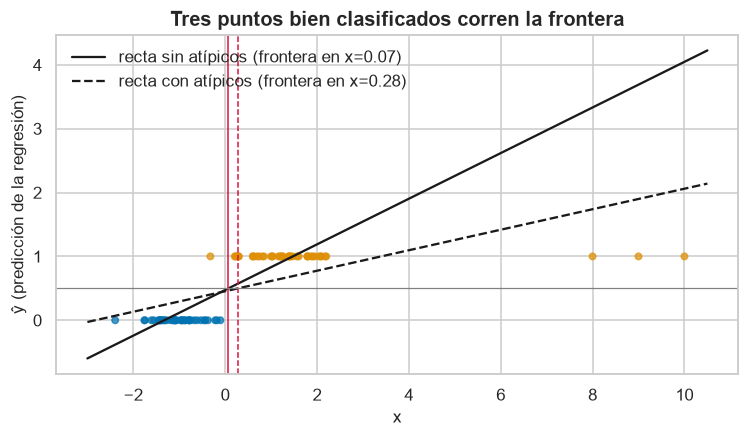

Errores de entrenamiento sin atípicos: 1 · con atípicos: 5


In [2]:
rng = np.random.default_rng(0)
x0 = rng.normal(-1, 0.6, 40)          # clase 0
x1 = rng.normal(1, 0.6, 40)           # clase 1
x = np.r_[x0, x1]
y = np.r_[np.zeros(40), np.ones(40)]

def frontera_ols(x, y):
    X = np.c_[np.ones_like(x), x]
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return b, (0.5 - b[0]) / b[1]      # donde b0 + b1*x = 0.5

b_sin, f_sin = frontera_ols(x, y)
x_out = np.r_[x, 8, 9, 10]             # tres clase 1 lejísimos, del lado correcto
y_out = np.r_[y, 1, 1, 1]
b_con, f_con = frontera_ols(x_out, y_out)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_out, y_out, c=[colores[int(v)] for v in y_out], s=18, alpha=0.7)
grilla = np.linspace(-3, 10.5, 200)
for b, f, est, nombre in [(b_sin, f_sin, "-", "sin atípicos"), (b_con, f_con, "--", "con atípicos")]:
    ax.plot(grilla, b[0] + b[1] * grilla, est, color="k", label=f"recta {nombre} (frontera en x={f:.2f})")
    ax.axvline(f, ls=est, color="crimson", lw=1)
ax.axhline(0.5, color="gray", lw=0.8)
ax.set(xlabel="x", ylabel="ŷ (predicción de la regresión)", title="Tres puntos bien clasificados corren la frontera")
ax.legend(loc="upper left"); plt.show()
print(f"Errores de entrenamiento sin atípicos: {np.sum((x > f_sin) != y)} · con atípicos: {np.sum((x_out > f_con) != y_out)}")

Mirá las dos cosas que muestra el gráfico. La recta llega a valores muy por encima de 1 (a la derecha) y por debajo de 0 (a la izquierda): no es una probabilidad. Y los tres puntos lejanos, que estaban perfectamente clasificados, **aplanan** la recta y corren la frontera (la vertical roja) hacia la derecha; el conteo de errores de abajo del gráfico dice cuántos puntos de entrenamiento pagan ese corrimiento.

Ahora el caso que la clase deja abierto con "¿Esto funciona?": tres clases alineadas en una sola variable.

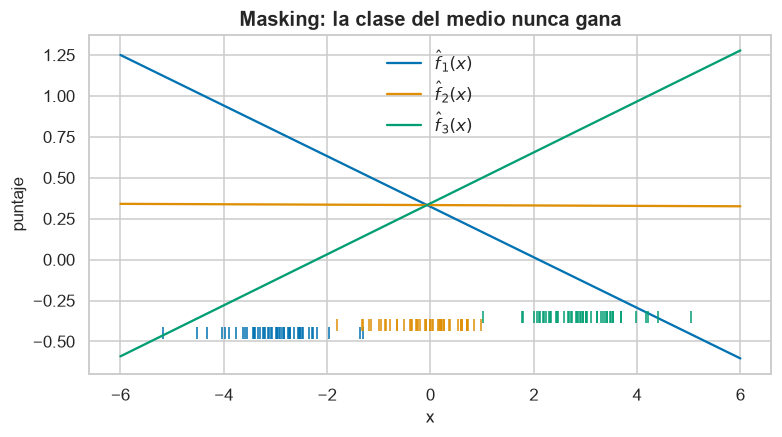

Suma de los 3 puntajes en 5 puntos de la grilla: [1. 1. 1. 1. 1.]
Cuántas veces se predice cada clase: [73  0 77]
Acierto en entrenamiento: 0.667


In [3]:
rng = np.random.default_rng(1)
centros = [-3, 0, 3]
x = np.concatenate([rng.normal(c, 0.8, 50) for c in centros])
g = np.repeat([0, 1, 2], 50)
Y = np.eye(3)[g]                       # matriz indicadora N x K: una fila de eye(3) por etiqueta
X = np.c_[np.ones_like(x), x]
B, *_ = np.linalg.lstsq(X, Y, rcond=None)   # (p+1) x K: una columna por clase

grilla = np.linspace(-6, 6, 300)
F = np.c_[np.ones_like(grilla), grilla] @ B
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(3):
    ax.plot(grilla, F[:, k], color=colores[k], label=f"$\\hat f_{k+1}(x)$")
    ax.plot(x[g == k], np.full(50, -0.45 + 0.05 * k), "|", color=colores[k], ms=8)
ax.set(xlabel="x", ylabel="puntaje", title="Masking: la clase del medio nunca gana")
ax.legend(); plt.show()

pred = (X @ B).argmax(axis=1)
print("Suma de los 3 puntajes en 5 puntos de la grilla:", F[::60].sum(axis=1).round(10))
print("Cuántas veces se predice cada clase:", np.bincount(pred, minlength=3))
print("Acierto en entrenamiento:", (pred == g).mean().round(3))

Esto es el **enmascaramiento** (*masking*, ESL §4.2). Las rayitas de abajo son los datos: tres grupos bien separados, cualquiera los clasificaría a ojo. Pero la recta de la clase del medio queda casi **plana** cerca de $1/3$. ¿Por qué? Porque la indicadora $Y_2$ vale 0 a la izquierda, 1 en el medio y 0 a la derecha: un "bulto". La mejor recta para aproximar un bulto simétrico es horizontal. Y una recta horizontal en $1/3$ pierde siempre contra alguna de las otras dos, que suben y bajan. El conteo lo confirma: la clase del medio no se predice **ni una sola vez**, y el acierto queda en $2/3$: exactamente las dos clases de los extremos.

Fijate también en la primera línea impresa: los tres puntajes suman exactamente 1 en todos los puntos, como probamos arriba.

El arreglo que propone ESL §4.2 es agregar términos cuadráticos ($x^2$) para que cada $\hat f_k$ pueda curvarse. Funciona acá, pero con $K$ clases en general hacen falta polinomios de grado hasta $K - 1$, y eso explota en cantidad de términos cuando $p$ es grande.

##### 🏭 Así se hace en la industria

La versión de librería es la misma regresión con salida multivariada. `LinearRegression` acepta una $\mathbf{Y}$ de $N \times K$ y ajusta las $K$ columnas de un saque:

In [4]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(x.reshape(-1, 1), Y)   # sklearn agrega el intercepto solo
B_sk = np.vstack([reg.intercept_, reg.coef_.T])      # mismo formato (p+1) x K que B
print("¿Coincide con lstsq?", np.allclose(B_sk, B))

¿Coincide con lstsq? True


En la práctica casi nadie clasifica así: se usa directamente LDA o regresión logística. Pero conviene saber que existe, porque es el primer lugar donde vas a ver el problema de masking, y porque en el caso $K = 2$ la dirección de la frontera que da coincide con la de LDA (📕 ESL §4.3 lo menciona; está desarrollado en la notebook del cap. 4).

### ⚠️ Confusión típica

Leer los $\hat f_k(x)$ como probabilidades porque suman 1. No lo son: pueden ser negativos o mayores que 1, y en el gráfico de masking, en los bordes de la grilla, ves valores cerca de $-0.6$ y de $1.25$. Lo que sí es cierto es que **para clasificar solo importa el orden** de los $\hat f_k(x)$, no su valor. Una aproximación pésima del posterior que respete el orden clasifica perfecto; masking es justo el caso en que la aproximación lineal **invierte** el orden en la zona de la clase del medio.

Segunda trampa: confundir "lineal" con "lineal en los parámetros". En la clase 2, "regresión lineal" quería decir lineal en $\beta$. En esta clase, "clasificador lineal" quiere decir que **la frontera** es un hiperplano en las variables de entrada. Son cosas distintas: la regresión logística es no lineal en $\beta$ (por la sigmoide) y sin embargo es un clasificador lineal.

### ❓ La pregunta que quedó abierta

La celda 4 termina con *"¿Esto funciona?"* y la clase pasa a LDA sin contestar. La respuesta tiene dos partes:

- **Con $K = 2$, en general sí**, con los dos defectos de la celda 2 (salidas fuera de $[0,1]$, sensibilidad a atípicos). No puede haber masking con dos clases, porque si los dos puntajes suman 1, gana el que supera $1/2$, y eso siempre ocurre de un lado de la frontera.
- **Con $K \ge 3$, puede fallar feo**, como viste: una clase entera puede quedar tapada aunque los datos estén perfectamente separados. Es justamente lo que el Ejercicio 1 te pide reproducir en dos dimensiones.

La otra pregunta de la celda 2, *"¿Y si la variable objetivo tiene más de dos clases?"*, la responde la propia celda 3: una indicadora por clase y $K$ regresiones en paralelo.

## 2. De Bayes a LDA: los ingredientes

📓 celdas 5–7 · 📕 ESL §4.3 · 📘 Bishop §4.2

### La idea en criollo

Una ferretería compra tornillos a dos fábricas. La fábrica A le vende el 70% y la B el 30%. Los de A miden alrededor de 5 cm y los de B alrededor de 5.4 cm, con algo de variación en ambas. Te dan un tornillo suelto de 5.3 cm: ¿de qué fábrica viene?

Para contestar combinás dos cosas. Cuánto **compra** la ferretería a cada una (sin mirar el tornillo, apostarías por A) y qué tan **típico** es un tornillo de 5.3 cm para cada fábrica (eso empuja hacia B). El teorema de Bayes es la receta exacta para combinarlas.

LDA es esa receta con un supuesto concreto sobre "qué tan típico": las medidas de cada fábrica siguen una campana normal, y **las dos campanas tienen el mismo ancho**; lo único que cambia es dónde están centradas.

> **Dónde se rompe la analogía.** En la ferretería, las proporciones y las campanas de cada fábrica serían datos conocidos. En LDA no conocés nada: suponés que la forma es normal y estimás centros, ancho y proporciones con los datos de entrenamiento (§4). Si las campanas reales no son normales o no tienen el mismo ancho, LDA igual te da una respuesta, pero ya no es la de Bayes.

### Formalizándolo

**Bayes (celda 5).** De la definición de probabilidad condicional:

$$P(G = k \mid X = x) = \frac{P(X = x \mid G = k)\,P(G = k)}{P(X = x)}.$$

La clase cambia la notación, y no es solo cosmética. $X$ es continua, así que $P(X = x)$ es literalmente cero para cualquier $x$ puntual; lo que tiene sentido es la **densidad**. Por eso los nombres nuevos:

- $\pi_k = P(G = k)$ es la **probabilidad a priori** de la clase $k$: qué proporción de la población pertenece a la clase $k$ antes de mirar $x$. Son probabilidades de un evento que seguro ocurre (alguna clase es), así que $\sum_{k=1}^K \pi_k = 1$.
- $f_k(x)$ es la **densidad de $X$ dentro de la clase $k$**: cómo se distribuyen las $x$ si te restringís a las observaciones de la clase $k$. Es una densidad, no una probabilidad: integra 1 sobre todo $\mathbb{R}^p$, pero puede valer más que 1 en un punto.

El denominador se reescribe con la **ley de probabilidad total**: la densidad de $X$ sin saber la clase es el promedio de las densidades por clase, ponderado por cuánto pesa cada clase.

$$f(x) = \sum_{m=1}^K f_m(x)\,\pi_m.$$

Usamos $m$ como índice de la suma para no confundirlo con el $k$ fijo del numerador. Queda:

$$P(G = k \mid X = x) = \frac{f_k(x)\,\pi_k}{\sum_{m=1}^K f_m(x)\,\pi_m}.$$

El lado izquierdo es el **posterior**: la probabilidad de la clase $k$ **después** de mirar $x$. La celda 5 cierra con *"es suficiente con aproximar cada elemento de la derecha"*: si tenés buenos $\pi_k$ y $f_k$, tenés el posterior, y con el posterior aplicás la regla de Bayes de la clase 1. A este enfoque se lo llama **generativo**: modelás cómo se generan las $x$ de cada clase, y de ahí deducís la clasificación.

**El modelo para $f_k$ (celda 6).** La normal multivariada:

$$f_k(x) = \frac{1}{(2\pi)^{p/2}\,|\mathbf{\Sigma}_k|^{1/2}}\, \exp\!\Big(-\tfrac{1}{2}(x - \mu_k)^T\mathbf{\Sigma}_k^{-1}(x - \mu_k)\Big).$$

Pieza por pieza:

- $\mu_k \in \mathbb{R}^p$ es el **vector de medias de la clase $k$**: el centro de la nube de puntos de esa clase.
- $\mathbf{\Sigma}_k$ es la **matriz de covarianza de $X$ dentro de la clase $k$**, de $p \times p$. En la diagonal tiene la varianza de cada variable *entre los puntos de la clase $k$*; fuera de la diagonal, la covarianza entre pares de variables, también dentro de la clase. Define la **forma y orientación** de la nube. No es "la covarianza de la etiqueta": la etiqueta está fija, lo que varía es $x$.
- $(x - \mu_k)^T\mathbf{\Sigma}_k^{-1}(x - \mu_k)$ es la **distancia de Mahalanobis al cuadrado** de $x$ al centro $\mu_k$. Es una distancia que se mide "en unidades de la nube": un paso en la dirección en que la nube es ancha cuenta poco; el mismo paso en la dirección en que es angosta cuenta mucho. Los puntos a igual distancia de Mahalanobis forman **elipses** (elipsoides en $p$ dimensiones).
- $|\mathbf{\Sigma}_k|$ es el **determinante** de $\mathbf{\Sigma}_k$, y junto con $(2\pi)^{p/2}$ forma la constante que hace que la densidad integre 1. Una nube más extendida tiene determinante más grande y por eso su densidad es más baja en el pico.

Chequeo de cordura: con $p = 1$, $\mathbf{\Sigma}_k$ es un número $\sigma_k^2$, $|\mathbf{\Sigma}_k|^{1/2} = \sigma_k$, $\mathbf{\Sigma}_k^{-1} = 1/\sigma_k^2$, y la fórmula queda $\frac{1}{\sqrt{2\pi}\sigma_k}\exp\!\big(-\frac{(x-\mu_k)^2}{2\sigma_k^2}\big)$: la normal de siempre.

**El supuesto de LDA (celdas 6–7).** Todas las clases comparten la misma covarianza:

$$\mathbf{\Sigma}_k = \mathbf{\Sigma} \quad \text{para todo } k.$$

Geométricamente: todas las nubes tienen **la misma forma elíptica y la misma orientación**, y solo cambian de lugar. Es un **supuesto de modelado**, no un hecho de los datos: lo elegís vos, y puede estar bien o mal. La celda 7 ya escribe $f_k$ con $\mathbf{\Sigma}$ sin subíndice, y eso es todo lo que hace falta para que la frontera salga lineal (§3).

### ¿Por qué nos importa?

Porque este es el otro gran camino para clasificar, y la clase entera va a oscilar entre los dos:

- **Generativo** (LDA, QDA): modelás $f_k$ y $\pi_k$, y el posterior sale de Bayes.
- **Discriminativo** (regresión logística, §7): modelás $P(G = k \mid X = x)$ directamente, sin decir nada sobre cómo se distribuyen las $x$.

El generativo te pide más supuestos, y a cambio usa más información de los datos. El supuesto de covarianza común es la perilla: si lo aflojás, sale QDA (§4).

### En código

Dos clases en $p = 2$ con la misma $\mathbf{\Sigma}$. Escribimos la densidad a mano, armamos el posterior con Bayes y miramos dónde vale $1/2$.

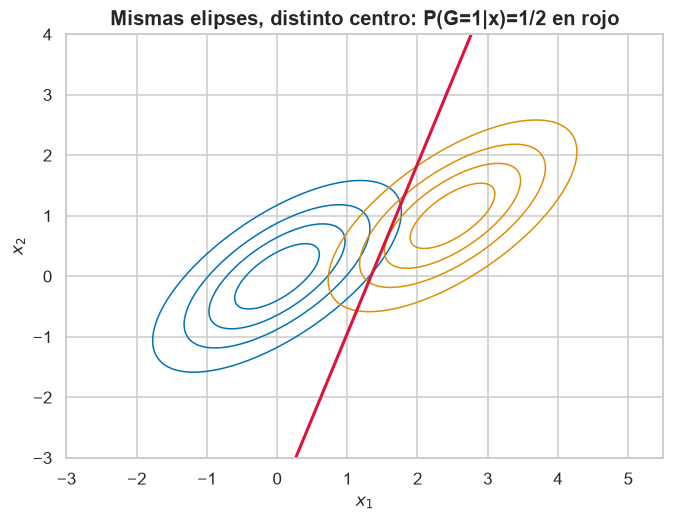

¿Los posteriores suman 1? True
Densidad en el centro con Σ/100 (una nube muy concentrada): [23.99]


In [5]:
def densidad_normal(x, mu, Sigma):
    """x: (n, p). Devuelve f(x) para cada fila, con la fórmula de la celda 6."""
    p = len(mu)
    d = x - mu
    maha = np.einsum("ij,jk,ik->i", d, np.linalg.inv(Sigma), d)   # (x-mu)^T Sigma^-1 (x-mu) fila por fila
    return np.exp(-0.5 * maha) / ((2 * np.pi) ** (p / 2) * np.sqrt(np.linalg.det(Sigma)))

mu = [np.array([0.0, 0.0]), np.array([2.5, 1.0])]
Sigma = np.array([[1.0, 0.6], [0.6, 0.8]])        # la MISMA para las dos clases
pi = np.array([0.7, 0.3])

g1, g2 = np.meshgrid(np.linspace(-3, 5.5, 250), np.linspace(-3, 4, 250))
grilla = np.c_[g1.ravel(), g2.ravel()]
f = np.column_stack([densidad_normal(grilla, m, Sigma) for m in mu])   # (n, K)
post = f * pi / (f * pi).sum(axis=1, keepdims=True)                     # Bayes, fila por fila

fig, ax = plt.subplots(figsize=(7, 5))
for k in range(2):
    ax.contour(g1, g2, f[:, k].reshape(g1.shape), levels=4, colors=[colores[k]], linewidths=1)
ax.contour(g1, g2, post[:, 0].reshape(g1.shape), levels=[0.5], colors="crimson", linewidths=2)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Mismas elipses, distinto centro: P(G=1|x)=1/2 en rojo")
plt.show()
print("¿Los posteriores suman 1?", np.allclose(post.sum(axis=1), 1))
origen = np.zeros((1, 2))
print("Densidad en el centro con Σ/100 (una nube muy concentrada):", densidad_normal(origen, origen[0], Sigma / 100).round(2))

Las elipses azules y naranjas son curvas de nivel de $f_1$ y $f_2$: misma forma, misma inclinación, distinto centro. La curva roja es donde el posterior vale exactamente $1/2$, la frontera de decisión de Bayes. Fijate que es una **recta**, aunque nadie le pidió que lo fuera: todavía no hicimos ninguna cuenta y ya se ve el resultado de §3.

La segunda línea impresa es para que no te quede duda de que $f_k$ es una densidad: si la nube es muy concentrada, en su centro vale mucho más que 1.

Fijate también que la recta no pasa por el punto medio entre los dos centros: está corrida hacia la clase 2. Es el prior: como la clase 1 pesa el 70%, hace falta estar más cerca de la clase 2 para que gane.

##### 🏭 Así se hace en la industria

Nadie escribe la densidad normal a mano: `scipy.stats.multivariate_normal` la tiene, y usa una descomposición de $\mathbf{\Sigma}$ en lugar de invertirla.

In [6]:
from scipy.stats import multivariate_normal

f_scipy = np.column_stack([multivariate_normal(mean=m, cov=Sigma).pdf(grilla) for m in mu])
print("¿Coincide con la versión a mano?", np.allclose(f_scipy, f))

¿Coincide con la versión a mano? True


### ⚠️ Confusión típica

Mezclar $f_k(x)$ con $P(G = k \mid X = x)$. Son dos preguntas al revés:

- $f_k(x)$: *sabiendo que es de la clase $k$*, ¿qué tan probable es ver una $x$ así? Es una densidad sobre $x$.
- $P(G = k \mid X = x)$: *sabiendo que vi esta $x$*, ¿qué tan probable es que sea de la clase $k$? Es una probabilidad sobre las clases, y suma 1 sobre $k$.

Un tornillo de 5.3 cm puede ser poco típico para las dos fábricas ($f_A$ y $f_B$ chicas), y aun así el posterior de B puede ser 0.9. El posterior es **relativo**: compara las clases entre sí.

Segunda trampa: creer que "covarianza común" quiere decir "variables independientes" o "covarianza identidad". No. $\mathbf{\Sigma}$ puede tener correlaciones (en el código, $0.6$ fuera de la diagonal, por eso las elipses están inclinadas). El supuesto es solo que **todas las clases tienen la misma**.

## 3. La frontera de LDA es un hiperplano

📓 celdas 8–13 · 📕 ESL §4.3 · 📘 Bishop §4.2.1

### La idea en criollo

Dos equipos de fútbol tiran de una soga, cada uno desde su arco. La frontera de decisión es el punto donde la soga queda quieta: los dos tiran con la misma fuerza. Para encontrarlo no hace falta saber cuánta fuerza total hay en la cancha; alcanza con saber **la diferencia** entre lo que tira cada uno.

Eso es lo que hace la cuenta de esta sección. En la fórmula de Bayes hay un montón de piezas, pero la frontera es donde dos posteriores empatan, y al restarlos **todo lo que es igual para las dos clases se cancela**. Lo que sobrevive es lineal en $x$.

> **Dónde se rompe la analogía.** La soga se mueve en una dimensión y queda quieta en un punto. Acá $x$ vive en $\mathbb{R}^p$ y el lugar de empate es todo un hiperplano. Además, con $K \ge 3$ clases no hay una sola soga: hay una frontera por cada par de clases, y la región de cada clase es donde le gana a **todas** las demás a la vez.

### Formalizándolo

**Paso 1: pasar a logaritmos (celda 8).** La frontera entre $k$ y $l$ es el conjunto de $x$ donde

$$P(G = k \mid X = x) = P(G = l \mid X = x).$$

Las dos probabilidades son positivas, y el logaritmo es estrictamente creciente, así que dos números positivos son iguales si y solo si sus logaritmos lo son. Restando y usando $\log a - \log b = \log(a/b)$:

$$\log \frac{P(G = k \mid X = x)}{P(G = l \mid X = x)} = 0.$$

¿Por qué conviene? Porque la densidad normal es una exponencial, y el logaritmo la "desarma" en sumas.

**Paso 2: el denominador de Bayes se cancela (celdas 9–10).** Tomando logaritmo de la fórmula de Bayes, con $\log(ab/c) = \log a + \log b - \log c$:

$$\log P(G = k \mid X = x) = \log f_k(x) + \log \pi_k - \log \sum_{m=1}^K f_m(x)\,\pi_m.$$

El último término **no tiene $k$ adentro**: es la misma suma sobre todas las clases sea cual sea la $k$ que estés mirando. Al restar el de la clase $l$, desaparece:

$$\log \frac{P(G = k \mid X = x)}{P(G = l \mid X = x)} = \log \frac{f_k(x)}{f_l(x)} + \log \frac{\pi_k}{\pi_l}.$$

Este paso vale para **cualquier** modelo de $f_k$, no solo el normal. Es la soga: la fuerza total no importa.

**Paso 3: el logaritmo de la normal (celda 11).** Usando $\log(ab) = \log a + \log b$, $\log(1/a) = -\log a$, $\log a^{c} = c \log a$ y $\log e^{u} = u$:

$$\log f_k(x) = -\frac{p}{2}\log(2\pi) - \frac{1}{2}\log|\mathbf{\Sigma}| - \frac{1}{2}(x - \mu_k)^T\mathbf{\Sigma}^{-1}(x - \mu_k).$$

Los dos primeros términos no dependen de $k$, **porque la $\mathbf{\Sigma}$ es la misma para todas las clases**. Se cancelan al restar. Este es el primer lugar donde se usa el supuesto de LDA:

$$\log \frac{P(G = k \mid X = x)}{P(G = l \mid X = x)} = -\frac{1}{2}(x - \mu_k)^T\mathbf{\Sigma}^{-1}(x - \mu_k) + \frac{1}{2}(x - \mu_l)^T\mathbf{\Sigma}^{-1}(x - \mu_l) + \log \frac{\pi_k}{\pi_l}.$$

**Paso 4: abrir las formas cuadráticas (celda 12).** La clase dice "aplicando la distributiva" y salta al resultado. Hagámoslo. Abrimos la primera como un binomio, usando que la transpuesta de una resta es la resta de las transpuestas:

$$(x - \mu_k)^T\mathbf{\Sigma}^{-1}(x - \mu_k) = x^T\mathbf{\Sigma}^{-1}x - x^T\mathbf{\Sigma}^{-1}\mu_k - \mu_k^T\mathbf{\Sigma}^{-1}x + \mu_k^T\mathbf{\Sigma}^{-1}\mu_k.$$

Los dos términos del medio son el **mismo número**. Cada uno es un escalar ($1 \times p$ por $p \times p$ por $p \times 1$), un escalar es igual a su transpuesta, y $\mathbf{\Sigma}^{-1}$ es simétrica porque $\mathbf{\Sigma}$ lo es:

$$\mu_k^T\mathbf{\Sigma}^{-1}x = (\mu_k^T\mathbf{\Sigma}^{-1}x)^T = x^T(\mathbf{\Sigma}^{-1})^T\mu_k = x^T\mathbf{\Sigma}^{-1}\mu_k.$$

Entonces

$$(x - \mu_k)^T\mathbf{\Sigma}^{-1}(x - \mu_k) = x^T\mathbf{\Sigma}^{-1}x - 2\,x^T\mathbf{\Sigma}^{-1}\mu_k + \mu_k^T\mathbf{\Sigma}^{-1}\mu_k,$$

y lo mismo con $l$. Ahora restamos (con el $-\frac12$ adelante de la de $k$ y el $+\frac12$ adelante de la de $l$):

$$-\tfrac{1}{2}\Big[\underbrace{x^T\mathbf{\Sigma}^{-1}x - x^T\mathbf{\Sigma}^{-1}x}_{=\,0}\; - 2x^T\mathbf{\Sigma}^{-1}\mu_k + 2x^T\mathbf{\Sigma}^{-1}\mu_l + \mu_k^T\mathbf{\Sigma}^{-1}\mu_k - \mu_l^T\mathbf{\Sigma}^{-1}\mu_l\Big]$$

**Esta es la línea clave de toda la sección**: el término cuadrático $x^T\mathbf{\Sigma}^{-1}x$ aparece igual en las dos clases y se cancela. Se cancela porque las dos usan **la misma** $\mathbf{\Sigma}$. Es el segundo lugar donde se usa el supuesto, y es el que hace que la frontera sea lineal.

Distribuyendo el $-\frac12$:

$$x^T\mathbf{\Sigma}^{-1}(\mu_k - \mu_l) - \tfrac{1}{2}\big(\mu_k^T\mathbf{\Sigma}^{-1}\mu_k - \mu_l^T\mathbf{\Sigma}^{-1}\mu_l\big).$$

Falta reconocer el paréntesis. Abrimos $(\mu_k + \mu_l)^T\mathbf{\Sigma}^{-1}(\mu_k - \mu_l)$:

$$\mu_k^T\mathbf{\Sigma}^{-1}\mu_k - \mu_k^T\mathbf{\Sigma}^{-1}\mu_l + \mu_l^T\mathbf{\Sigma}^{-1}\mu_k - \mu_l^T\mathbf{\Sigma}^{-1}\mu_l.$$

Los dos cruzados son iguales (mismo argumento de escalar y simetría) con signo opuesto, se cancelan, y queda exactamente el paréntesis. Es la diferencia de cuadrados $a^2 - b^2 = (a+b)(a-b)$, versión matricial. Juntando todo:

$$\boxed{\log \frac{P(G = k \mid X = x)}{P(G = l \mid X = x)} = \log \frac{\pi_k}{\pi_l} - \tfrac{1}{2}(\mu_k + \mu_l)^T\mathbf{\Sigma}^{-1}(\mu_k - \mu_l) + x^T\mathbf{\Sigma}^{-1}(\mu_k - \mu_l)}$$

Esto tiene la forma $\beta_0 + \beta^T x$ con

$$\beta = \mathbf{\Sigma}^{-1}(\mu_k - \mu_l), \qquad \beta_0 = \log \frac{\pi_k}{\pi_l} - \tfrac{1}{2}(\mu_k + \mu_l)^T\mathbf{\Sigma}^{-1}(\mu_k - \mu_l).$$

Igualado a cero, es un hiperplano.

#### Cómo leer la frontera

Las dos piezas tienen significado:

- **La dirección** $\beta = \mathbf{\Sigma}^{-1}(\mu_k - \mu_l)$ es el vector **normal** al hiperplano (perpendicular a él). Si $\mathbf{\Sigma}$ fuera la identidad, sería $\mu_k - \mu_l$: la frontera sería perpendicular al segmento que une los centros. $\mathbf{\Sigma}^{-1}$ la **gira** para tener en cuenta la forma de las nubes.
- **La posición.** Si $\pi_k = \pi_l$, el punto medio $x = \frac{1}{2}(\mu_k + \mu_l)$ da exactamente cero: la frontera pasa por el medio de los centros. El término $\log(\pi_k/\pi_l)$ la **corre** hacia la clase menos probable, que es lo que viste en el gráfico de §2.

**Paso 5: la función discriminante (celda 13).** Si en vez de restar dos clases te quedás, para cada clase, con los términos de $\log P(G = k \mid X = x)$ que dependen de $k$, obtenés:

$$\delta_k(x) = x^T\mathbf{\Sigma}^{-1}\mu_k - \tfrac{1}{2}\mu_k^T\mathbf{\Sigma}^{-1}\mu_k + \log \pi_k.$$

$\delta_k$ (leelo "delta ka") es la **función discriminante lineal** de la clase $k$: un puntaje por clase, como los $\hat f_k$ de §1. ¿Qué tiramos para llegar acá? Tres cosas: el denominador de Bayes, las constantes $-\frac{p}{2}\log 2\pi - \frac12\log|\mathbf{\Sigma}|$, y $-\frac{1}{2}x^T\mathbf{\Sigma}^{-1}x$. Las tres son iguales para todas las clases. Entonces

$$\log P(G = k \mid X = x) = \delta_k(x) + c(x),$$

con $c(x)$ un término que depende de $x$ pero **no de $k$**. Para un $x$ fijo, sumarle la misma constante a todos los puntajes no cambia cuál es el máximo, y el logaritmo no cambia el orden. Por eso

$$\hat G(x) = \arg\max_k \delta_k(x) = \arg\max_k P(G = k \mid X = x),$$

que es la regla de Bayes. Y la frontera entre $k$ y $l$ es $\delta_k(x) = \delta_l(x)$, porque $\delta_k(x) - \delta_l(x)$ es exactamente el log-cociente que calculamos (la $c(x)$ se cancela).

### ¿Por qué nos importa?

Porque te da la receta completa para clasificar con LDA: calcular $K$ puntajes lineales y quedarte con el mayor. No hace falta calcular ninguna densidad ni ningún denominador. Y te dice exactamente **qué supuesto compra la linealidad**: la $\mathbf{\Sigma}$ común, que mata el término $x^T\mathbf{\Sigma}^{-1}x$. Cuando en §4 lo aflojemos, sabrás de antemano qué va a sobrevivir.

### En código

Usamos los mismos parámetros de §2. Comprobamos tres cosas: que el $\arg\max$ de los $\delta_k$ coincide con el del posterior en toda la grilla, que $\delta_1 - \delta_2$ es el log-cociente de posteriores, y que sobre la recta $\beta_0 + \beta^Tx = 0$ el posterior vale $1/2$.

In [7]:
Sinv = np.linalg.inv(Sigma)

def deltas(x, mus, Sinv, pis):
    """Funciones discriminantes lineales de la celda 13, una columna por clase."""
    return np.column_stack([x @ Sinv @ m - 0.5 * m @ Sinv @ m + np.log(p_) for m, p_ in zip(mus, pis)])

D = deltas(grilla, mu, Sinv, pi)
print("¿argmax δ_k == argmax posterior en toda la grilla?", np.array_equal(D.argmax(1), post.argmax(1)))
print("¿δ_1 - δ_2 == log(P1/P2)?", np.allclose(D[:, 0] - D[:, 1], np.log(post[:, 0] / post[:, 1])))

# La recta de la celda 12: beta0 + beta^T x = 0
beta = Sinv @ (mu[0] - mu[1])
beta0 = np.log(pi[0] / pi[1]) - 0.5 * (mu[0] + mu[1]) @ Sinv @ (mu[0] - mu[1])
x1s = np.linspace(-2, 4, 5)
sobre_recta = np.c_[x1s, -(beta0 + beta[0] * x1s) / beta[1]]    # despejo x2
f_r = np.column_stack([densidad_normal(sobre_recta, m, Sigma) for m in mu]) * pi
print("Posterior de la clase 1 sobre la recta:", (f_r[:, 0] / f_r.sum(1)).round(6))
print("β =", beta, " β0 =", round(beta0, 4))

¿argmax δ_k == argmax posterior en toda la grilla? True
¿δ_1 - δ_2 == log(P1/P2)? True
Posterior de la clase 1 sobre la recta: [0.5 0.5 0.5 0.5 0.5]
β = [-3.1818  1.1364]  β0 = 4.2564


Las tres comprobaciones salen bien: el posterior sobre la recta da $0.5$ en todos los puntos que probamos. Fijate en $\beta$: si $\mathbf{\Sigma}$ fuera la identidad, la dirección sería $\mu_1 - \mu_2 = (-2.5, -1)$. Con la $\mathbf{\Sigma}$ correlacionada sale otro vector: eso es el "giro" de $\mathbf{\Sigma}^{-1}$.

Ahora con tres clases, para ver que las regiones se arman comparando todos los puntajes a la vez:

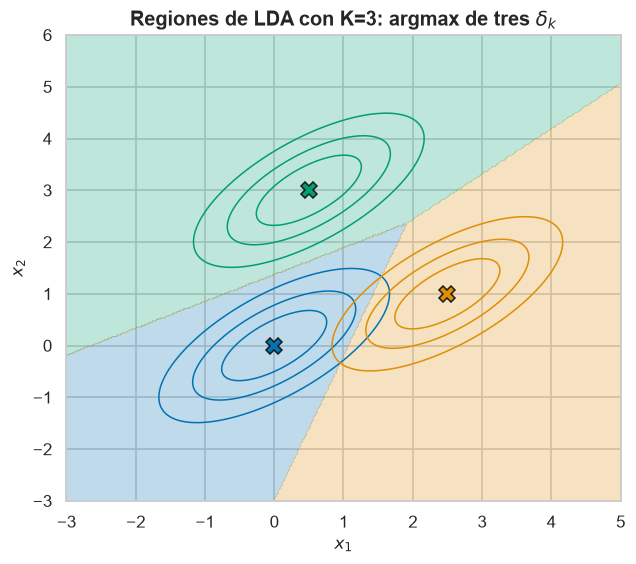

In [8]:
mu3 = [np.array([0.0, 0.0]), np.array([2.5, 1.0]), np.array([0.5, 3.0])]
pi3 = np.array([1 / 3, 1 / 3, 1 / 3])
g1b, g2b = np.meshgrid(np.linspace(-3, 5, 300), np.linspace(-3, 6, 300))
grilla3 = np.c_[g1b.ravel(), g2b.ravel()]
region = deltas(grilla3, mu3, Sinv, pi3).argmax(1).reshape(g1b.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.contourf(g1b, g2b, region, levels=[-0.5, 0.5, 1.5, 2.5], colors=colores[:3], alpha=0.25)
for k, m in enumerate(mu3):
    ax.contour(g1b, g2b, densidad_normal(grilla3, m, Sigma).reshape(g1b.shape), levels=3, colors=[colores[k]], linewidths=1)
    ax.plot(*m, "X", color=colores[k], ms=10, mec="k")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title=r"Regiones de LDA con K=3: argmax de tres $\delta_k$")
plt.show()

Cada región es la zona donde una clase le gana a las otras dos. Los bordes son tramos de recta que se juntan en un único punto, donde los tres $\delta_k$ empatan. Cada región es un **polígono convexo** (intersección de semiplanos): esto vale para cualquier clasificador que elija el máximo de puntajes lineales, incluida la regresión sobre indicadoras de §1.

### ⚠️ Confusión típica

Creer que $\delta_k(x)$ es $\log P(G = k \mid X = x)$. No lo es: le falta $c(x)$, así que no podés hacer $e^{\delta_k}$ y leerlo como probabilidad. Si querés el posterior, lo recuperás normalizando: $P(G = k \mid X = x) = e^{\delta_k(x)} / \sum_m e^{\delta_m(x)}$, porque la $e^{c(x)}$ aparece arriba y abajo y se cancela.

Segunda trampa: pensar que la frontera lineal sale de que la normal es "simple". Sale de la **covarianza compartida**. Si cada clase tuviera su $\mathbf{\Sigma}_k$, la misma cuenta con las mismas normales daría una frontera curva. Eso es §4.

### ❓ La pregunta que quedó abierta

La celda 7 pregunta *"¿Cómo obtenemos fronteras de decisión?"* y la celda 8 arranca a contestarla, pero nunca dice por qué basta con mirar **pares** de clases cuando hay $K$ clases. La respuesta: un punto $x$ va a la clase $k$ si $\delta_k(x) > \delta_l(x)$ para **todas** las $l \ne k$. Cada una de esas desigualdades es un semiplano (un lado de la frontera $k$–$l$), así que la región de $k$ es la intersección de $K - 1$ semiplanos. Las fronteras de a pares son las piezas; la región se arma intersecándolas, como viste en el gráfico de tres clases. No toda frontera de a pares termina apareciendo: si dos clases no son vecinas, su recta de empate cae dentro de la región de una tercera y no se ve.

## 4. Estimar los parámetros, y QDA

📓 celdas 14–15 · 📕 ESL §4.3 · 📘 Bishop §4.2.2

### La idea en criollo

Hasta acá jugamos con parámetros conocidos. En la vida real tenés una tabla de datos con etiquetas y nada más. La salida es la más directa posible: **reemplazar cada parámetro por su versión empírica**. ¿Qué proporción de la población es de la clase $k$? La proporción en tu muestra. ¿Dónde está el centro de la clase $k$? El promedio de sus puntos. Este truco de "enchufar estimaciones donde iban los verdaderos" se llama *plug-in*.

La parte delicada es la covarianza. LDA dice que todas las clases tienen la misma forma de nube. Para estimar esa forma común, juntás a todos los puntos pero **cada uno medido desde el centro de su propia clase**. Es como superponer las $K$ nubes corriendo cada una hasta que su centro quede en el origen, y medir la forma de la nube resultante.

> **Dónde se rompe la analogía.** "Superponer las nubes" sugiere que el resultado es una sola nube de $N$ puntos con su covarianza de siempre, dividida por $N - 1$. Pero al centrar cada clase en **su propia media estimada** gastaste $K$ grados de libertad, no uno. Por eso el divisor es $N - K$, y lo justificamos abajo.

### Formalizándolo

**Los estimadores (celda 14).** Con $N_k$ la cantidad de observaciones de la clase $k$ y $N = \sum_k N_k$:

$$\hat\pi_k = \frac{N_k}{N}, \qquad \hat\mu_k = \frac{1}{N_k}\sum_{g_i = k} x_i, \qquad \hat{\mathbf{\Sigma}} = \frac{1}{N - K}\sum_{k=1}^K \sum_{g_i = k}(x_i - \hat\mu_k)(x_i - \hat\mu_k)^T.$$

Cómo leerlos:

- La notación $\sum_{g_i = k}$ quiere decir "sumá sobre las observaciones $i$ cuya etiqueta $g_i$ es $k$".
- $\hat\mu_k$ es un **vector** de $p$ componentes: el promedio se hace coordenada por coordenada. La clase lo subraya con *"recordar que $x$ es multivariado"*.
- $(x_i - \hat\mu_k)(x_i - \hat\mu_k)^T$ es un **producto exterior**: un vector columna de $p \times 1$ por uno fila de $1 \times p$ da una matriz de $p \times p$. Su entrada $(j, l)$ es $(x_{ij} - \hat\mu_{kj})(x_{il} - \hat\mu_{kl})$: cuánto se desvían juntas las variables $j$ y $l$ en ese punto.
- $\hat{\mathbf{\Sigma}}$ se llama covarianza **agrupada** (*pooled*): agrupa las desviaciones de todas las clases.

**Por qué cada punto se centra en la media de su clase.** Si centraras en la media global, la covarianza mediría también cuánto se separan las clases entre sí. Pero $\mathbf{\Sigma}$ en el modelo es la forma de la nube **dentro** de cada clase. La separación entre clases ya está en los $\mu_k$; no tiene que contaminar a $\mathbf{\Sigma}$.

**Por qué $N - K$.** Es el mismo fenómeno que el $N - 1$ de la varianza muestral de la clase 3: los residuos respecto de una media estimada son, en promedio, un poco más chicos que respecto de la media verdadera, porque la media estimada se acomoda a los datos. Para una sola clase con $N_k$ observaciones normales vale

$$E\Big[\sum_{g_i = k}(x_i - \hat\mu_k)(x_i - \hat\mu_k)^T\Big] = (N_k - 1)\,\mathbf{\Sigma}.$$

Es la versión matricial del resultado de una variable, y se prueba igual: se agrega y se resta $\mu_k$ adentro del paréntesis y se usa que $\text{Cov}(\hat\mu_k) = \mathbf{\Sigma}/N_k$. Sumando sobre las $K$ clases:

$$E\Big[\sum_{k=1}^K\sum_{g_i = k}(\cdots)(\cdots)^T\Big] = \sum_{k=1}^K (N_k - 1)\,\mathbf{\Sigma} = (N - K)\,\mathbf{\Sigma}.$$

Dividir por $N - K$ hace al estimador **insesgado**. Si estimaras por máxima verosimilitud, dividirías por $N$, como pasaba con $\hat\sigma^2$ en la clase 3. Con $N$ grande y $K$ chico la diferencia es despreciable; con clases chicas, no.

Una forma equivalente que ayuda a entenderlo: si $\mathbf{S}_k$ es la covarianza muestral de la clase $k$ sola (con divisor $N_k - 1$), entonces

$$\hat{\mathbf{\Sigma}} = \sum_{k=1}^K \frac{N_k - 1}{N - K}\,\mathbf{S}_k,$$

un **promedio ponderado** de las covarianzas de cada clase, donde pesa más la clase que tiene más datos.

**QDA: soltar el supuesto (celda 15).** La clase pregunta *"¿Qué ocurría si no asumíamos que todas las clases compartían la misma matriz de covarianza?"*. Volvamos a la cuenta de §3 con una $\mathbf{\Sigma}_k$ distinta para cada clase y miremos qué deja de cancelarse:

$$\log f_k(x) = -\frac{p}{2}\log(2\pi) - \frac{1}{2}\log|\mathbf{\Sigma}_k| - \frac{1}{2}(x - \mu_k)^T\mathbf{\Sigma}_k^{-1}(x - \mu_k).$$

- $-\frac{p}{2}\log(2\pi)$ sigue sin depender de $k$: se va.
- $-\frac12\log|\mathbf{\Sigma}_k|$ ahora **sí** depende de $k$: se queda.
- Al abrir la forma cuadrática aparece $-\frac12 x^T\mathbf{\Sigma}_k^{-1}x$, que ahora **es distinto para cada clase**: se queda. Ese es el término cuadrático en $x$ que en LDA se cancelaba.

Quedándonos con todo lo que depende de $k$ (más $\log\pi_k$), sale la **función discriminante cuadrática**:

$$\delta_k(x) = -\frac{1}{2}\log|\mathbf{\Sigma}_k| - \frac{1}{2}(x - \mu_k)^T\mathbf{\Sigma}_k^{-1}(x - \mu_k) + \log\pi_k.$$

Cómo leerla: la clase gana puntos si $x$ está cerca de su centro **en la distancia de Mahalanobis de su propia nube**, pierde $\frac12\log|\mathbf{\Sigma}_k|$ si su nube es muy extendida (una nube grande reparte su densidad en mucho espacio y es baja en cada punto), y suma su prior.

La frontera entre $k$ y $l$ es $\delta_k(x) = \delta_l(x)$, que en $x$ tiene la forma

$$\tfrac12 x^T(\mathbf{\Sigma}_l^{-1} - \mathbf{\Sigma}_k^{-1})x + (\text{algo lineal en } x) + \text{constante} = 0.$$

Es una **cuádrica**: en el plano, una elipse, una parábola, una hipérbola o un par de rectas. Si $\mathbf{\Sigma}_k = \mathbf{\Sigma}_l$ la matriz del término cuadrático es cero y volvés a LDA: **LDA es el caso particular de QDA** con covarianzas iguales.

Para estimar, ahora cada clase tiene su propia covarianza: $\hat{\mathbf{\Sigma}}_k = \frac{1}{N_k - 1}\sum_{g_i = k}(x_i - \hat\mu_k)(x_i - \hat\mu_k)^T$, que es la $\mathbf{S}_k$ de arriba.

### ¿Por qué nos importa?

Porque te deja elegir **cuánta flexibilidad pagar**. Contá parámetros. Una matriz de covarianza de $p \times p$ simétrica tiene $p(p+1)/2$ entradas libres. LDA estima una sola; QDA estima $K$. Con $p = 50$ y $K = 3$: LDA estima $1275$ números de covarianza, QDA $3825$. Más parámetros con los mismos datos es más varianza en las estimaciones: el compromiso sesgo–varianza de siempre. LDA puede ser más estable aun cuando las covarianzas verdaderas difieren un poco.

Es el mismo dilema que tuviste con Ridge y Lasso en las clases 4 y 5, y ESL lo resuelve de la misma manera, con un punto intermedio: el *análisis discriminante regularizado*, que mezcla $\hat{\mathbf{\Sigma}}_k$ con $\hat{\mathbf{\Sigma}}$ (📕 ESL §4.3.1).

### En código

Primero, el divisor. Simulamos muchas veces 3 clases con solo 5 puntos cada una, todas con la misma $\mathbf{\Sigma}$ verdadera, y promediamos las estimaciones agrupadas con divisor $N - K$ y con divisor $N$.

In [9]:
rng = np.random.default_rng(2)
Sigma_v = np.array([[1.0, 0.5], [0.5, 2.0]])
K, Nk, reps = 3, 5, 20_000
N = K * Nk

acum = np.zeros((2, 2))
for _ in range(reps):
    dispersion = np.zeros((2, 2))
    for k in range(K):
        Xk = rng.multivariate_normal([3.0 * k, 0], Sigma_v, Nk)
        R = Xk - Xk.mean(axis=0)         # residuos respecto de la media de SU clase
        dispersion += R.T @ R            # suma de productos exteriores de la celda 14
    acum += dispersion

print("Σ verdadera:\n", Sigma_v)
print("Promedio con divisor N-K:\n", (acum / reps / (N - K)).round(3))
print("Promedio con divisor N:\n", (acum / reps / N).round(3))

Σ verdadera:
 [[1.  0.5]
 [0.5 2. ]]
Promedio con divisor N-K:
 [[0.999 0.497]
 [0.497 1.998]]
Promedio con divisor N:
 [[0.799 0.398]
 [0.398 1.599]]


Con divisor $N - K = 12$ el promedio cae sobre la $\mathbf{\Sigma}$ verdadera. Con divisor $N = 15$ queda sistemáticamente más chica, en un factor $12/15 = 0.8$. Fijate que `R.T @ R` es la suma de los productos exteriores $(x_i - \hat\mu_k)(x_i - \hat\mu_k)^T$ de toda la clase de una sola vez: si $\mathbf{R}$ tiene los residuos en las filas, $\mathbf{R}^T\mathbf{R} = \sum_i r_i r_i^T$.

Ahora el caso donde LDA no tiene nada que hacer: dos clases **con el mismo centro**, una compacta y otra extendida. La dirección de LDA es $\mathbf{\Sigma}^{-1}(\mu_1 - \mu_2) = 0$: no hay hiperplano que las separe. QDA sí puede.

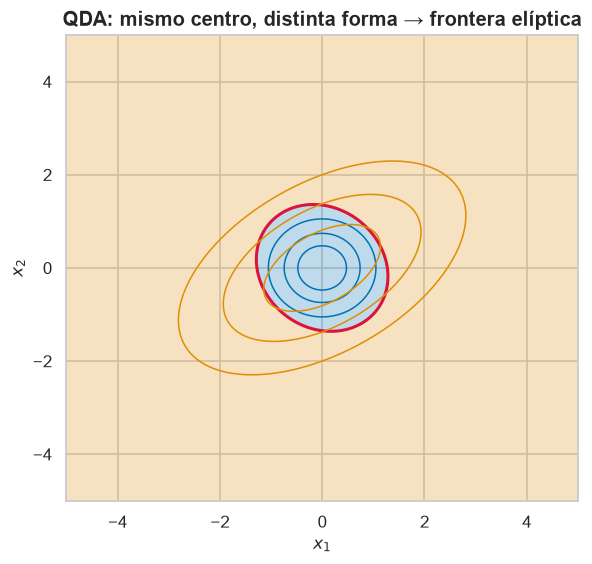

In [10]:
mu_q = [np.zeros(2), np.zeros(2)]
Sig_q = [np.array([[0.4, 0.0], [0.0, 0.4]]), np.array([[3.0, 1.2], [1.2, 2.0]])]
pi_q = np.array([0.5, 0.5])

g1c, g2c = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
gq = np.c_[g1c.ravel(), g2c.ravel()]
# Bayes directo con la densidad de §2: cada clase con SU covarianza
Dq = np.log(np.column_stack([densidad_normal(gq, m, S) for m, S in zip(mu_q, Sig_q)]) * pi_q)
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.contourf(g1c, g2c, Dq.argmax(1).reshape(g1c.shape), levels=[-0.5, 0.5, 1.5], colors=colores[:2], alpha=0.25)
ax.contour(g1c, g2c, (Dq[:, 0] - Dq[:, 1]).reshape(g1c.shape), levels=[0], colors="crimson", linewidths=2)
for k in range(2):
    ax.contour(g1c, g2c, densidad_normal(gq, mu_q[k], Sig_q[k]).reshape(g1c.shape), levels=3, colors=[colores[k]], linewidths=1)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="QDA: mismo centro, distinta forma → frontera elíptica")
plt.show()

La frontera roja es una **elipse**: adentro gana la clase compacta (azul), afuera la extendida (naranja). Ningún clasificador lineal puede hacer esto, porque un hiperplano deja a cada clase de un solo lado, y acá la clase naranja está de los dos lados de la azul.

Fijate que la elipse no coincide con ninguna curva de nivel de las dos densidades: es donde las dos densidades **valen lo mismo**, que depende de ambas formas y de los determinantes.

Fijate en un detalle del código: no usamos $\delta_k$, sino $\log(f_k(x)\pi_k)$ calculado con la densidad de §2. Es lo mismo salvo la constante $-\frac{p}{2}\log 2\pi$, que no cambia ni el $\arg\max$ ni la frontera. Escribir los $\delta_k$ de QDA y estimarlos con datos te toca en el Ejercicio 2, y la comparación con `sklearn` es el Ejercicio 3.

### ⚠️ Confusión típica

Estimar la covarianza común con `np.cov` de todos los datos juntos. Eso centra en la media **global** y mete la separación entre clases adentro de $\hat{\mathbf{\Sigma}}$: con clases bien separadas te da una covarianza enorme y estirada en la dirección que une los centros, justo la dirección donde LDA necesita ver las nubes angostas. La covarianza agrupada se arma **clase por clase**.

Segunda trampa, para QDA: olvidarse del término $-\frac12\log|\mathbf{\Sigma}_k|$. En LDA no aparecía porque se cancelaba; en QDA no se cancela, y sin él la clase de nube grande gana zonas que no le corresponden.

## 5. Esferizar: LDA como centroide más cercano

📓 celdas 16–19 · 📕 ESL §4.3.1–§4.3.3

### La idea en criollo

Las nubes de LDA son elipses inclinadas. Medir distancias en una elipse inclinada es incómodo: un paso de 1 cm a lo largo del eje largo "vale" menos que un paso de 1 cm a lo ancho. Por eso aparece la distancia de Mahalanobis, con su $\mathbf{\Sigma}^{-1}$ en el medio.

Imaginate que el plano es una lámina de goma con las elipses dibujadas. Primero la **girás** hasta que los ejes de las elipses queden alineados con los ejes horizontal y vertical. Después la **estirás o comprimís** en cada eje hasta que las elipses se vuelvan **círculos**. En la lámina transformada, la distancia de Mahalanobis es la distancia de regla de siempre. Y clasificar con LDA se vuelve: "andá al centro más cercano" (con una corrección por el prior).

> **Dónde se rompe la analogía.** Funciona porque todas las clases tienen **la misma** elipse: un único giro y un único estiramiento las redondea a todas a la vez. En QDA cada clase tiene su elipse, y no hay una sola deformación de la lámina que las vuelva círculos a todas. Ahí la descomposición se hace clase por clase y solo sirve para calcular más fácil, no para tener un espacio común.

### Formalizándolo

**La pregunta de la celda 16.** *"¿No sería más conveniente si este elipsoide estuviera alineado con (algunos) ejes?"* Sí. Si la elipse está alineada con los ejes, $\mathbf{\Sigma}$ es **diagonal** (no hay covarianzas, solo varianzas), y la inversa de una diagonal es la diagonal de los inversos: $\text{diag}(\lambda_1, \ldots, \lambda_p)^{-1} = \text{diag}(1/\lambda_1, \ldots, 1/\lambda_p)$. Nada que resolver. La idea es no *suponer* que la elipse está alineada, sino **girar los ejes** para que lo esté.

**La descomposición espectral (celda 17).** Toda matriz simétrica real se puede escribir como

$$\hat{\mathbf{\Sigma}}_k = \mathbf{U}_k\mathbf{D}_k\mathbf{U}_k^T.$$

Es el **teorema espectral**, y garantiza dos cosas:

- $\mathbf{U}_k$ es **ortogonal**: sus columnas son los autovectores de $\hat{\mathbf{\Sigma}}_k$, tienen norma 1 y son perpendiculares entre sí. En fórmulas, $\mathbf{U}_k^T\mathbf{U}_k = \mathbf{U}_k\mathbf{U}_k^T = \mathbf{I}$, así que $\mathbf{U}_k^{-1} = \mathbf{U}_k^T$. Geométricamente, multiplicar por $\mathbf{U}_k^T$ es una **rotación** (o reflexión): no cambia longitudes. Las columnas de $\mathbf{U}_k$ son las direcciones de los ejes de la elipse.
- $\mathbf{D}_k = \text{diag}(\lambda_{k1}, \ldots, \lambda_{kp})$ tiene los **autovalores**. El autovalor $\lambda_{kl}$ es la varianza de la nube a lo largo del eje $l$. Si además $\hat{\mathbf{\Sigma}}_k$ es definida positiva (la clase lo asume), todos son estrictamente positivos.

Es la misma familia que la SVD de la clase 3: para una matriz simétrica definida positiva, la descomposición espectral y la SVD coinciden. Más abajo vemos que la conexión es todavía más directa: los $\mathbf{U}_k$ y $\mathbf{D}_k$ se pueden **calcular** con la SVD de los residuos.

**Notación.** $\lambda_{kl}$ tiene dos subíndices: $k$ es la clase y $l$ el eje ($l = 1, \ldots, p$). Escribo todo con $\hat{\mathbf{\Sigma}}_k$ porque así sirve para QDA; para LDA es la misma cuenta con la $\hat{\mathbf{\Sigma}}$ común, sacándole el subíndice $k$ a todo. El 📒 cuaderno de ESL (§4.3.2) llama $\mathbf{W}$ a esa $\hat{\mathbf{\Sigma}}$ común y $d_\ell$ a sus autovalores; acá son $\hat{\mathbf{\Sigma}}$ y $\lambda_l$.

**¿Para qué la queremos?** Primero, lo que **no** hace: la descomposición no estima nada. $\hat{\mathbf{\Sigma}}_k$ ya la tenemos: es el plug-in de §4. Acá solo la **usamos**. Para evaluar el $\delta_k$ de QDA de §4 hacen falta, por cada clase, dos cosas que dependen de $\hat{\mathbf{\Sigma}}_k$: la **inversa** $\hat{\mathbf{\Sigma}}_k^{-1}$, adentro de la distancia de Mahalanobis, y el **log-determinante** $\log|\hat{\mathbf{\Sigma}}_k|$. La descomposición escribe las dos en términos de los $\lambda_{kl}$, que son varianzas a lo largo de los ejes de la elipse: números que se pueden leer, en lugar de una matriz llena de entradas sin interpretación directa.

**La inversa (celda 18).** Una regla previa: la inversa de un producto es el producto de las inversas **en orden contrario**, $(\mathbf{A}\mathbf{B}\mathbf{C})^{-1} = \mathbf{C}^{-1}\mathbf{B}^{-1}\mathbf{A}^{-1}$. Se comprueba multiplicando: en $(\mathbf{A}\mathbf{B}\mathbf{C})(\mathbf{C}^{-1}\mathbf{B}^{-1}\mathbf{A}^{-1})$ se cancela primero el $\mathbf{C}\mathbf{C}^{-1}$ del medio, después $\mathbf{B}\mathbf{B}^{-1}$, y queda $\mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$. Aplicada a $\hat{\mathbf{\Sigma}}_k = \mathbf{U}_k\mathbf{D}_k\mathbf{U}_k^T$, con $\mathbf{U}_k^{-1} = \mathbf{U}_k^T$ y $(\mathbf{U}_k^T)^{-1} = \mathbf{U}_k$:

$$\hat{\mathbf{\Sigma}}_k^{-1} = (\mathbf{U}_k^T)^{-1}\,\mathbf{D}_k^{-1}\,\mathbf{U}_k^{-1} = \mathbf{U}_k\mathbf{D}_k^{-1}\mathbf{U}_k^T, \qquad \mathbf{D}_k^{-1} = \text{diag}(1/\lambda_{k1}, \ldots, 1/\lambda_{kp}).$$

**La línea clave:** los ejes quedan iguales y cada varianza se reemplaza por su inversa. Invertir la matriz se redujo a invertir $p$ números. Eso exige que todos los $\lambda_{kl}$ sean $> 0$ (no se puede dividir por cero), y ahí es donde se usa que $\hat{\mathbf{\Sigma}}_k$ sea definida positiva. Si querés convencerte sin la regla, multiplicá: $(\mathbf{U}_k\mathbf{D}_k\mathbf{U}_k^T)(\mathbf{U}_k\mathbf{D}_k^{-1}\mathbf{U}_k^T) = \mathbf{U}_k\mathbf{D}_k\underbrace{\mathbf{U}_k^T\mathbf{U}_k}_{\mathbf{I}}\mathbf{D}_k^{-1}\mathbf{U}_k^T = \mathbf{U}_k\mathbf{U}_k^T = \mathbf{I}$.

**Qué queda de la distancia de Mahalanobis.** Llamemos $z = \mathbf{U}_k^T(x - \mu_k)$: son las coordenadas de $x - \mu_k$ medidas sobre los ejes de la elipse (multiplicar por $\mathbf{U}_k^T$ es girar). Como $(\mathbf{A}v)^T = v^T\mathbf{A}^T$, el vector fila de la izquierda es $(x - \mu_k)^T\mathbf{U}_k = z^T$, y entonces

$$(x - \mu_k)^T\hat{\mathbf{\Sigma}}_k^{-1}(x - \mu_k) = \underbrace{(x - \mu_k)^T\mathbf{U}_k}_{z^T}\,\mathbf{D}_k^{-1}\,\underbrace{\mathbf{U}_k^T(x - \mu_k)}_{z} = \sum_{l=1}^p \frac{z_l^2}{\lambda_{kl}} = \sum_{l=1}^p \Big(\frac{z_l}{\sqrt{\lambda_{kl}}}\Big)^2.$$

El paso del medio vale porque $\mathbf{D}_k^{-1}$ es diagonal: $z^T\mathbf{D}_k^{-1}z$ no tiene términos cruzados. Leámosla con números. Una nube con varianzas $\lambda_1 = 4$ y $\lambda_2 = 1$ en sus ejes, y un punto en $z = (2, 1)$. Dividiendo cada coordenada por su desvío, $z_l/\sqrt{\lambda_l} = (2/2,\ 1/1) = (1, 1)$, y la distancia al cuadrado es $1^2 + 1^2 = 2$. Las 2 unidades sobre el eje largo pesan lo mismo que la unidad sobre el eje corto, porque las dos son **un desvío estándar**. Mahalanobis cuenta desvíos, no centímetros. La última forma, $\sum_l (z_l/\sqrt{\lambda_{kl}})^2$, es una receta: girá, dividí cada coordenada por su desvío y medí con regla. Guardala, porque es exactamente la esferización que formalizamos más abajo (celda 18, segunda mitad).

**El determinante.** Dos propiedades que usamos sin demostrar: el determinante de un producto es el producto de los determinantes, y el de una matriz diagonal es el producto de su diagonal. Para $\mathbf{U}_k$ alcanza con $|\mathbf{U}_k|\,|\mathbf{U}_k^T| = |\mathbf{U}_k\mathbf{U}_k^T| = |\mathbf{I}| = 1$ (de hecho $|\mathbf{U}_k| = \pm1$: girar o reflejar no cambia volúmenes). Entonces

$$|\hat{\mathbf{\Sigma}}_k| = |\mathbf{U}_k|\,|\mathbf{D}_k|\,|\mathbf{U}_k^T| = \prod_{l=1}^p \lambda_{kl} \quad\Rightarrow\quad \log|\hat{\mathbf{\Sigma}}_k| = \sum_{l=1}^p \log\lambda_{kl}.$$

**El determinante es un volumen.** La elipse de los puntos a distancia de Mahalanobis 1 del centro tiene semiejes $\sqrt{\lambda_{k1}}, \ldots, \sqrt{\lambda_{kp}}$: sobre el eje $l$, $z_l^2/\lambda_{kl} = 1$ da $z_l = \sqrt{\lambda_{kl}}$. Su volumen es proporcional al producto de los semiejes, $\prod_l \sqrt{\lambda_{kl}} = \sqrt{|\hat{\mathbf{\Sigma}}_k|}$. En el plano, es el área de la elipse, $\pi\sqrt{\lambda_{k1}}\sqrt{\lambda_{k2}}$. **La línea clave:** el término de QDA

$$-\tfrac12\log|\hat{\mathbf{\Sigma}}_k| = -\log\sqrt{|\hat{\mathbf{\Sigma}}_k|} = -\log(\text{volumen de la elipse}) + \text{constante}$$

es el castigo a la nube grande que en §4 dijimos en palabras: la densidad tiene que integrar 1, y si se reparte en más volumen, es más baja en cada punto. En QDA cada clase paga el logaritmo del tamaño de su propia nube.

**Qué se gana, y qué no.** Con las dos cuentas de arriba, cada $\delta_k$ de QDA se arma con una rotación, $p$ divisiones y $p$ logaritmos. Pero no lo leas como "es más rápido": diagonalizar $\hat{\mathbf{\Sigma}}_k$ cuesta del orden de $p^3$ operaciones, igual que invertirla (con una constante algo mayor), y en los dos casos se hace una sola vez al entrenar. Lo que se gana es otra cosa:

1. **Un log-determinante que no se rompe.** El determinante es un producto de $p$ números. Con $p$ grande se va a $0$ o a $\infty$ en la computadora, aunque su logaritmo sea un número perfectamente normal. Lo que lo salva es **sumar logaritmos** en lugar de multiplicar. Para eso no hace falta diagonalizar (`np.linalg.slogdet` lo hace con otra factorización), pero con los $\lambda_{kl}$ en la mano sale gratis.
2. **Se ve qué anda mal.** Esto sí es propio de la descomposición. Un $\lambda_{kl}$ casi cero es una dirección en la que la clase casi no varía, y dividir por él (en $z_l^2/\lambda_{kl}$) multiplica el ruido de esa dirección por un número enorme. Con la inversa calculada de frente eso queda escondido; con los $\lambda$ a la vista, se ve, y se puede corregir. Es lo que hace el dial $\gamma$ de RDA (📒 cuaderno de ESL, §4.3.1), que mezcla $\hat{\mathbf{\Sigma}}$ con una esfera: $\hat{\mathbf{\Sigma}}(\gamma) = \gamma\hat{\mathbf{\Sigma}} + (1-\gamma)\hat\sigma^2\mathbf{I}$, con $\gamma \in [0, 1]$ y $\hat\sigma^2$ un escalar, una varianza típica (por ejemplo, el promedio de la diagonal de $\hat{\mathbf{\Sigma}}$). Como $\mathbf{I} = \mathbf{U}\mathbf{U}^T$, la mezcla es $\mathbf{U}\big(\gamma\mathbf{D} + (1-\gamma)\hat\sigma^2\mathbf{I}\big)\mathbf{U}^T$: **los mismos ejes**, con autovalores $\gamma\lambda_l + (1-\gamma)\hat\sigma^2$. Los chicos se levantan hacia $\hat\sigma^2$. Es el gesto de Ridge de la clase 4, que suma un múltiplo de $\mathbf{I}$ a $\mathbf{X}^T\mathbf{X}$.

Las dos cosas, en código. Primero un determinante con $p = 400$; después, una variable casi duplicada y el efecto de $\gamma$ sobre sus autovalores.

In [11]:
# 1) El determinante es un producto de p autovalores: con p grande se escapa de los números de la máquina
rng = np.random.default_rng(6)
A_det = rng.normal(size=(1000, 400)) * 0.3           # N = 1000, p = 400, varianza 0.09 por variable
S_det = np.cov(A_det.T)
with np.errstate(all="ignore"):                      # silenciamos los avisos de under/overflow
    det_directo = np.linalg.det(S_det)
    print("det directo:", det_directo, "  → su log:", np.log(det_directo))
print("suma de los log λ:", np.log(np.linalg.eigvalsh(S_det)).sum().round(2))

# 2) Una variable casi duplicada: un autovalor casi cero, y su eje dice cuál es la dirección problemática
B = rng.normal(size=(50, 3))
X_col = np.c_[B, B[:, 0] + 1e-6 * rng.normal(size=50)]   # 4ta variable = 1ra + ruido ínfimo
S_col = np.cov(X_col.T)
lam_col, U_col = np.linalg.eigh(S_col)                    # eigh ordena de menor a mayor
print("\nautovalores:", [f"{v:.1e}" for v in lam_col])
print("eje del más chico:", U_col[:, 0].round(3))

# 3) El dial γ de RDA: mismos ejes, autovalores levantados hacia σ²
gam, s2 = 0.9, np.trace(S_col) / 4
print("autovalores con γ = 0.9:", np.linalg.eigvalsh(gam * S_col + (1 - gam) * s2 * np.eye(4)).round(4))
print("γλ + (1-γ)σ²:           ", (gam * lam_col + (1 - gam) * s2).round(4))

det directo: 0.0   → su log: -inf
suma de los log λ: -1055.59

autovalores: ['4.7e-13', '5.7e-01', '1.1e+00', '2.7e+00']
eje del más chico: [ 0.707 -0.    -0.    -0.707]
autovalores con γ = 0.9: [0.1082 0.6197 1.0589 2.5395]
γλ + (1-γ)σ²:            [0.1082 0.6197 1.0589 2.5395]


Tres cosas para mirar en la salida.

1. `np.linalg.det` devuelve **exactamente cero**, y su logaritmo, $-\infty$. El determinante verdadero no es cero: es del orden de $e^{-1056}$, demasiado chico para un `float`. La suma de los logaritmos lo calcula sin problema.
2. Con la variable casi duplicada, el autovalor más chico es del orden de $10^{-13}$, y su eje es, salvo signo, $(0.707, 0, 0, -0.707)$: la dirección $x_1 - x_4$, justo la combinación que casi no varía. Dividir por ese $\lambda$ multiplicaría unas $10^{12}$ veces cualquier ruido en esa dirección. La inversa calculada de frente no te avisa; los autovalores sí.
3. Con $\gamma = 0.9$, los autovalores coinciden (hasta el redondeo) con $\gamma\lambda_l + (1-\gamma)\hat\sigma^2$, y el más chico pasó a ser un número razonable. Es la fórmula de arriba, comprobada.

**LDA en el espacio esferizado (celda 18, segunda mitad).** Con la covarianza común $\hat{\mathbf{\Sigma}} = \mathbf{U}\mathbf{D}\mathbf{U}^T$ definimos la transformación

$$x^* = \mathbf{D}^{-1/2}\mathbf{U}^T x,$$

donde $\mathbf{D}^{-1/2} = \text{diag}(1/\sqrt{\lambda_1}, \ldots, 1/\sqrt{\lambda_p})$. Leela de derecha a izquierda: $\mathbf{U}^T$ **gira** hasta alinear la elipse con los ejes, y $\mathbf{D}^{-1/2}$ **divide** cada eje por su desvío estándar.

*¿Por qué la covarianza se vuelve la identidad?* Si $X$ tiene covarianza $\mathbf{\Sigma}$ dentro de cada clase y $\mathbf{A}$ es una matriz fija, entonces $\mathbf{A}X$ tiene covarianza $\mathbf{A}\mathbf{\Sigma}\mathbf{A}^T$. Con $\mathbf{A} = \mathbf{D}^{-1/2}\mathbf{U}^T$:

$$\mathbf{A}\mathbf{\Sigma}\mathbf{A}^T = \mathbf{D}^{-1/2}\mathbf{U}^T(\mathbf{U}\mathbf{D}\mathbf{U}^T)\mathbf{U}\mathbf{D}^{-1/2} = \mathbf{D}^{-1/2}\mathbf{D}\,\mathbf{D}^{-1/2} = \mathbf{I}.$$

Las nubes ahora son esferas (de ahí "esferizar"). Las medias se transforman igual: $\hat\mu_k^* = \mathbf{D}^{-1/2}\mathbf{U}^T\hat\mu_k$.

*¿Por qué la regla queda "centroide más cercano"?* La clase da la regla final sin la cuenta. Es corta. Primero, $\mathbf{\Sigma}^{-1} = \mathbf{U}\mathbf{D}^{-1}\mathbf{U}^T = (\mathbf{D}^{-1/2}\mathbf{U}^T)^T(\mathbf{D}^{-1/2}\mathbf{U}^T) = \mathbf{A}^T\mathbf{A}$. Entonces cada producto con $\mathbf{\Sigma}^{-1}$ se vuelve un producto interno común entre vectores transformados:

$$x^T\mathbf{\Sigma}^{-1}\mu_k = (\mathbf{A}x)^T(\mathbf{A}\mu_k) = x^{*T}\mu_k^*, \qquad \mu_k^T\mathbf{\Sigma}^{-1}\mu_k = \|\mu_k^*\|^2.$$

Reemplazando en el $\delta_k$ de §3:

$$\delta_k(x) = x^{*T}\mu_k^* - \tfrac12\|\mu_k^*\|^2 + \log\pi_k.$$

Ahora completamos el cuadrado. Como $\|x^* - \mu_k^*\|^2 = \|x^*\|^2 - 2x^{*T}\mu_k^* + \|\mu_k^*\|^2$, despejando:

$$x^{*T}\mu_k^* - \tfrac12\|\mu_k^*\|^2 = -\tfrac12\|x^* - \mu_k^*\|^2 + \tfrac12\|x^*\|^2.$$

Entonces $\delta_k(x) = -\big(\tfrac12\|x^* - \mu_k^*\|^2 - \log\pi_k\big) + \tfrac12\|x^*\|^2$. El último término no depende de $k$, y maximizar $-a$ es minimizar $a$:

$$\hat G(x) = \arg\max_k \delta_k(x) = \arg\min_k\Big\{\tfrac12\|x^* - \hat\mu_k^*\|^2 - \log\hat\pi_k\Big\}.$$

Es la fórmula de la celda 18. Si las clases son igual de probables, es **literalmente** el centroide más cercano en distancia euclídea.

**Traducción de notación.** La clase escribe $x^* = \mathbf{D}^{-1/2}\mathbf{U}^Tx$ con $x$ como **vector columna** (una observación). Con la matriz de datos $\mathbf{X}$ de $N \times p$, donde cada observación es una **fila**, lo mismo se escribe $\mathbf{X}^* = \mathbf{X}\mathbf{U}\mathbf{D}^{-1/2}$: transponer $\mathbf{D}^{-1/2}\mathbf{U}^Tx$ da $x^T\mathbf{U}\mathbf{D}^{-1/2}$. Es la forma que vas a usar en `numpy`.

**Reducción de dimensionalidad (celda 19).** La clase lo deja para el libro, pero la idea central sale de la fórmula que acabamos de probar. En el espacio esferizado, los $K$ centroides $\hat\mu_1^*, \ldots, \hat\mu_K^*$ son $K$ puntos, y $K$ puntos siempre caben en un subespacio afín de dimensión **a lo sumo $K - 1$** (dos puntos definen una recta, tres un plano). Descomponé $x^*$ en su parte **dentro** de ese subespacio y su parte **perpendicular**. Por Pitágoras, la parte perpendicular suma la **misma** cantidad a la distancia a todos los centroides, así que no cambia cuál es el más cercano. Conclusión: podés proyectar los datos sobre ese subespacio de $K - 1$ dimensiones **sin perder nada** para clasificar. Con $p = 1000$ variables y $K = 3$ clases, LDA vive en un plano.

ESL §4.3.3 va más allá: dentro de esas $K - 1$ dimensiones, ordena las direcciones según cuánto separan los centroides (es el problema de Fisher: maximizar la varianza **entre** clases relativa a la varianza **dentro** de las clases). Por eso la clase dice que es una reducción de dimensionalidad **supervisada**: usa las etiquetas. PCA, en cambio, busca las direcciones de mayor varianza total sin mirar las etiquetas, y esas pueden ser justo las que no separan nada. El 📒 cuaderno de ESL (§4.3.3) desarrolla este paso con Fisher y con el dial $L$ de cuántas dimensiones conservar.

### ¿Por qué nos importa?

Por tres razones. **Cálculo**: es como lo implementan las librerías. No porque sea más rápido (ya vimos que no lo es), sino porque deja a la vista los autovalores chicos y permite tratarlos. **Intuición**: LDA deja de ser una fórmula y pasa a ser "centroide más cercano, con la regla bien calibrada". **Visualización**: la proyección a $K - 1$ dimensiones es una de las mejores maneras de dibujar datos de muchas variables con etiquetas.

### En código

Datos de dos clases con covarianza común inclinada. Los comparamos en tres versiones: originales, estandarizados variable por variable, y esferizados con la covarianza agrupada.

In [12]:
rng = np.random.default_rng(3)
Sig_e = np.array([[2.0, 1.5], [1.5, 1.6]])
Xe = np.vstack([rng.multivariate_normal(m, Sig_e, 150) for m in ([0, 0], [1.5, -1.0])])
ge = np.repeat([0, 1], 150)

medias = np.array([Xe[ge == k].mean(0) for k in range(2)])
R = Xe - medias[ge]                               # cada punto menos la media de SU clase
S_pool = R.T @ R / (len(Xe) - 2)                  # covarianza agrupada, divisor N-K
lam, U = np.linalg.eigh(S_pool)                   # eigh: para simétricas, autovalores reales y U ortogonal
Xs = Xe @ U @ np.diag(lam ** -0.5)                # versión por filas: X* = X U D^{-1/2}
Xz = (Xe - Xe.mean(0)) / Xe.std(0)                # estandarización común

def cov_dentro(Z):
    medias_z = np.array([Z[ge == k].mean(0) for k in range(2)])
    Rz = Z - medias_z[ge]
    return Rz.T @ Rz / (len(Z) - 2)

for nombre, Z in [("original", Xe), ("estandarizada", Xz), ("esferizada", Xs)]:
    print(f"Covarianza dentro de clase, {nombre}:\n{cov_dentro(Z).round(3)}\n")

Covarianza dentro de clase, original:
[[2.073 1.547]
 [1.547 1.599]]

Covarianza dentro de clase, estandarizada:
[[0.778 0.713]
 [0.713 0.905]]

Covarianza dentro de clase, esferizada:
[[ 1. -0.]
 [-0.  1.]]



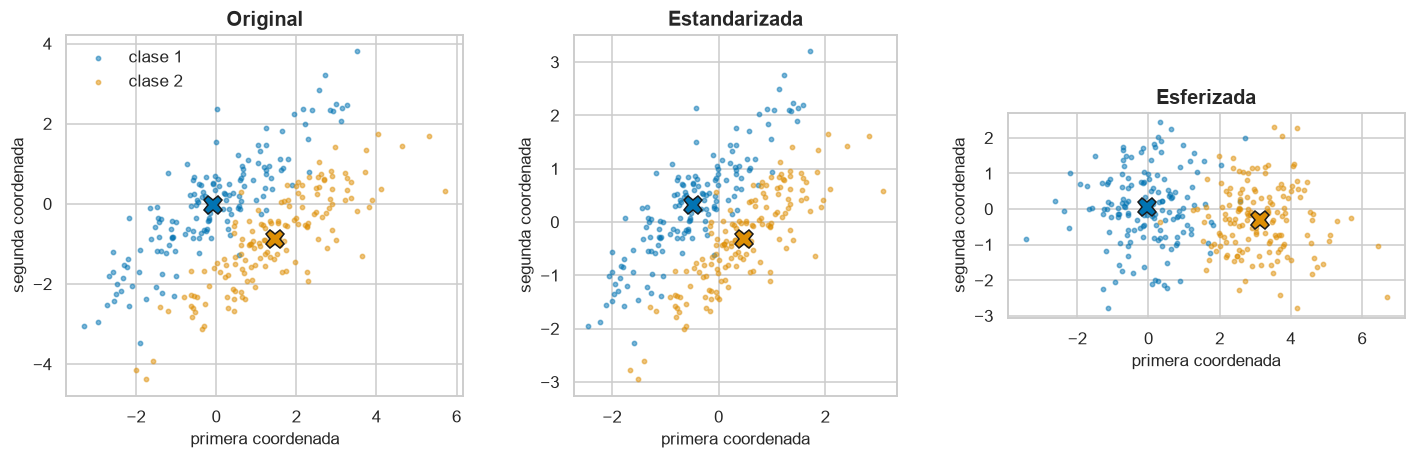

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, Z, titulo in zip(axes, [Xe, Xz, Xs], ["Original", "Estandarizada", "Esferizada"]):
    for k in range(2):
        ax.scatter(*Z[ge == k].T, s=8, alpha=0.5, color=colores[k], label=f"clase {k + 1}")
        ax.plot(*Z[ge == k].mean(0), "X", color=colores[k], ms=12, mec="k")
    ax.set_aspect("equal"); ax.set(title=titulo, xlabel="primera coordenada", ylabel="segunda coordenada")
axes[0].legend(loc="upper left")
plt.tight_layout(); plt.show()

Mirá la diagonal de cada matriz impresa y lo que está fuera de ella. La estandarizada achicó las varianzas, pero ni siquiera las dejó en 1: dentro de cada clase quedan por debajo, porque el desvío que usó para dividir incluye la separación entre las clases. Y conserva una covarianza **fuera de la diagonal** grande: las nubes siguen inclinadas (panel del medio). La esferizada da la identidad: nubes redondas (panel derecho). En el panel derecho la distancia de regla al centroide es la distancia de Mahalanobis original.

Comprobamos que el centroide más cercano corregido por el prior da exactamente las mismas predicciones que $\arg\max_k\delta_k$:

In [14]:
pis_e = np.bincount(ge) / len(ge)
mus_s = medias @ U @ np.diag(lam ** -0.5)          # las medias se transforman igual que los datos
dist = 0.5 * ((Xs[:, None, :] - mus_s[None, :, :]) ** 2).sum(-1) - np.log(pis_e)
pred_centroide = dist.argmin(1)
pred_delta = deltas(Xe, list(medias), np.linalg.inv(S_pool), pis_e).argmax(1)
print("¿Mismas predicciones?", np.array_equal(pred_centroide, pred_delta))
print("¿U es ortogonal?", np.allclose(U.T @ U, np.eye(2)), "· autovalores:", lam.round(3))

¿Mismas predicciones? True
¿U es ortogonal? True · autovalores: [0.271 3.402]


> 🔗 **Conexión con la clase 3: los ejes y los autovalores de $\hat{\mathbf{\Sigma}}$ salen de una SVD.** El estimador sigue siendo el mismo, $\hat{\mathbf{\Sigma}} = \mathbf{R}^T\mathbf{R}/(N - K)$. Lo que cambia es la forma de calcularlo. En la celda de código donde armamos `R` y `S_pool` (la de las tres covarianzas), $\mathbf{R}$ es la matriz de $N \times p$ de residuos: fila $i$, $x_i - \hat\mu_{g_i}$, cada punto menos la media de su clase. La clase 3 descompone cualquier matriz con la SVD. Para no pisar letras la escribimos $\mathbf{R} = \mathbf{U}_R\mathbf{S}\mathbf{V}^T$: $\mathbf{U}_R$ ($N \times p$) y $\mathbf{V}$ ($p \times p$) con columnas ortonormales, y $\mathbf{S} = \text{diag}(s_1, \ldots, s_p)$ con los valores singulares. Igual que $\mathbf{X}^T\mathbf{X} = \mathbf{V}\mathbf{D}^2\mathbf{V}^T$ en la clase 3:
>
> $$\hat{\mathbf{\Sigma}} = \frac{\mathbf{R}^T\mathbf{R}}{N - K} = \frac{\mathbf{V}\mathbf{S}\overbrace{\mathbf{U}_R^T\mathbf{U}_R}^{\mathbf{I}}\mathbf{S}\mathbf{V}^T}{N - K} = \mathbf{V}\,\frac{\mathbf{S}^2}{N - K}\,\mathbf{V}^T.$$
>
> Comparando con $\hat{\mathbf{\Sigma}} = \mathbf{U}\mathbf{D}\mathbf{U}^T$: los ejes de la elipse son los vectores singulares **derechos** de los residuos ($\mathbf{U} = \mathbf{V}$, salvo orden y signos) y cada autovalor es $\lambda_l = s_l^2/(N - K)$. Ojo con la notación: en la clase 3, $\mathbf{D}$ tenía **valores singulares**; acá tiene **autovalores**, que son esos valores al cuadrado divididos por $N - K$.
>
> ¿Para qué sirve? Por lo mismo que en la clase 3: armar $\mathbf{R}^T\mathbf{R}$ eleva al cuadrado el número de condición, y los autovalores chicos, justo los que $\mathbf{D}^{-1/2}$ amplifica, son los que más precisión pierden. Por eso `LinearDiscriminantAnalysis` con `solver="svd"` (el que usa por defecto) hace algo equivalente: divide los residuos por el desvío dentro de clase de cada variable, les hace la SVD, **descarta** los valores singulares casi nulos y no arma nunca $\hat{\mathbf{\Sigma}}$ (salvo que le pidas `store_covariance=True`). Lo comprobamos con el `R` de esa celda:

In [15]:
U_R, s, Vt = np.linalg.svd(R, full_matrices=False)       # SVD fina de los residuos (clase 3)
print("s²/(N-K), ordenados:", np.sort(s**2 / (len(Xe) - 2)).round(4))
print("autovalores de eigh:", lam.round(4))
# svd ordena de mayor a menor y eigh de menor a mayor; los signos de cada eje son arbitrarios
print("¿Mismos ejes (salvo signo)?", np.allclose(np.abs(Vt[::-1]), np.abs(U.T)))

s²/(N-K), ordenados: [0.2706 3.4015]
autovalores de eigh: [0.2706 3.4015]
¿Mismos ejes (salvo signo)? True


##### 🏭 Así se hace en la industria

`LinearDiscriminantAnalysis` hace la esferización por dentro y expone la proyección a $K - 1$ dimensiones con `.transform`. Con el dataset *iris* ($p = 4$ variables, $K = 3$ especies) la proyección de LDA tiene 2 dimensiones. Al lado, PCA con 2 componentes, que no mira las etiquetas.

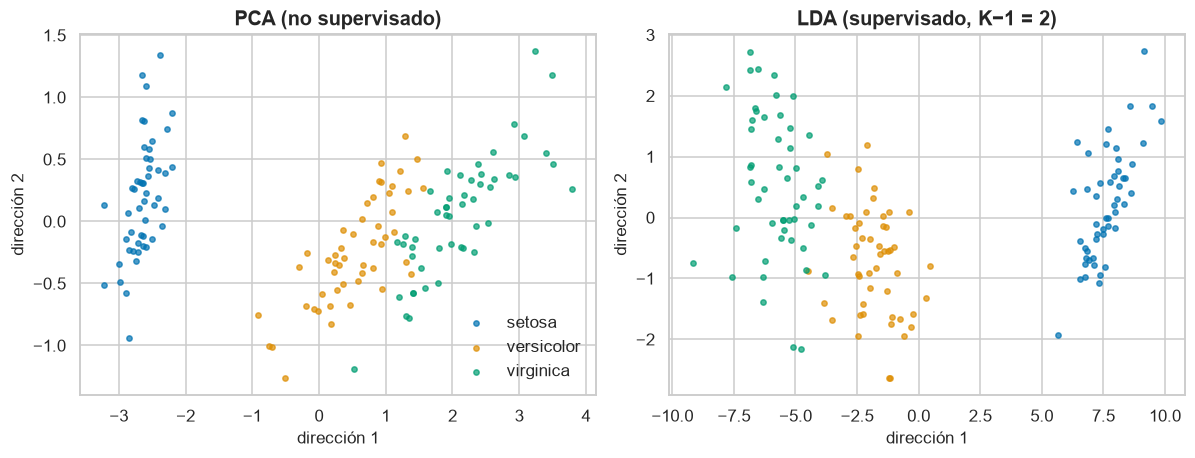

In [16]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Xi, gi = load_iris(return_X_y=True)
Z_lda = LinearDiscriminantAnalysis(n_components=2).fit(Xi, gi).transform(Xi)
Z_pca = PCA(n_components=2).fit_transform(Xi)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, Z, titulo in zip(axes, [Z_pca, Z_lda], ["PCA (no supervisado)", "LDA (supervisado, K−1 = 2)"]):
    for k, nombre in enumerate(load_iris().target_names):
        ax.scatter(*Z[gi == k].T, s=12, alpha=0.7, color=colores[k], label=nombre)
    ax.set(title=titulo, xlabel="dirección 1", ylabel="dirección 2")
axes[0].legend(); plt.tight_layout(); plt.show()

En LDA, la primera dirección sola ya aparta a *setosa* por mucho y deja a *versicolor* y *virginica* con un solapamiento chico: está elegida para separar. En PCA, *versicolor* y *virginica* se pisan más, porque la dirección de mayor varianza total no es necesariamente la que mejor separa clases. Es la diferencia entre supervisado y no supervisado de la celda 19, en un gráfico.

#### ¿Importa si estandarizo antes de LDA?

No (📕 ESL §4.3.2). Si cambiás las variables por $x \to \mathbf{A}x + b$, con $\mathbf{A}$ inversible (estandarizar es un caso: restar medias y dividir por desvíos), LDA da **las mismas predicciones**. Las estimaciones se transforman igual que los datos: $\hat\mu_k \to \mathbf{A}\hat\mu_k + b$ (promediar conmuta con $\mathbf{A}x + b$) y $\hat{\mathbf{\Sigma}} \to \mathbf{A}\hat{\mathbf{\Sigma}}\mathbf{A}^T$ (la regla $\text{Cov}(\mathbf{A}X) = \mathbf{A}\mathbf{\Sigma}\mathbf{A}^T$ de arriba). Entonces $x - \hat\mu_k \to \mathbf{A}(x - \hat\mu_k)$, porque el $b$ se cancela, y por la regla de la inversa de un producto, $(\mathbf{A}\hat{\mathbf{\Sigma}}\mathbf{A}^T)^{-1} = (\mathbf{A}^T)^{-1}\hat{\mathbf{\Sigma}}^{-1}\mathbf{A}^{-1}$:

$$\big(\mathbf{A}(x - \hat\mu_k)\big)^T(\mathbf{A}^T)^{-1}\hat{\mathbf{\Sigma}}^{-1}\mathbf{A}^{-1}\big(\mathbf{A}(x - \hat\mu_k)\big) = (x - \hat\mu_k)^T\underbrace{\mathbf{A}^T(\mathbf{A}^T)^{-1}}_{\mathbf{I}}\hat{\mathbf{\Sigma}}^{-1}\underbrace{\mathbf{A}^{-1}\mathbf{A}}_{\mathbf{I}}(x - \hat\mu_k) = (x - \hat\mu_k)^T\hat{\mathbf{\Sigma}}^{-1}(x - \hat\mu_k).$$

**La línea clave:** las $\mathbf{A}$ se cancelan de a pares en el medio. La distancia de Mahalanobis no cambia, los priors tampoco, y el $\arg\max$ queda igual. Vale también para QDA: el determinante pasa a $|\mathbf{A}|^2|\hat{\mathbf{\Sigma}}_k|$, y el $\log|\mathbf{A}|^2$ que aparece es el mismo para todas las clases. Comparalo con Ridge y Lasso (clases 4 y 5), donde estandarizar o no cambia la solución. Es esperable: Mahalanobis ya mide en desvíos, así que la escala de las variables no le importa. La invarianza se pierde al regularizar con $\gamma$, porque $\hat\sigma^2\mathbf{I}$ no se transforma como $\mathbf{A}\hat{\mathbf{\Sigma}}\mathbf{A}^T$.
### ⚠️ Confusión típica

Esferizar con la covarianza **total** (la de `np.cov(X.T)`) en lugar de la agrupada dentro de clases. La total incluye la separación entre centros; si la usás, achicás justamente la dirección que separa las clases. Para LDA se esferiza con $\hat{\mathbf{\Sigma}}$ **dentro** de clase.

Segunda trampa: creer que, después de esferizar, el prior ya no importa. El término $-\log\hat\pi_k$ sigue en la regla. Solo con priors iguales es centroide más cercano puro.

### ❓ La pregunta que quedó abierta

La celda 18 cierra con *"¿Cuál es la diferencia con una estandarización normal?"*. Son tres diferencias:

1. **Estandarizar no gira.** Divide cada variable por su desvío, por separado. Es multiplicar por una matriz **diagonal**. Si las variables están correlacionadas, la elipse sigue inclinada (lo viste en el panel del medio). Esferizar primero gira con $\mathbf{U}^T$ y después escala, así que elimina también las correlaciones.
2. **Estandarizar usa la variabilidad total; esferizar, la de dentro de clase.** La estandarización común no mira las etiquetas: su desvío incluye la distancia entre clases. La esferización de LDA usa $\hat{\mathbf{\Sigma}}$, que es la forma de cada nube alrededor de su propio centro.
3. **Lo que logran.** Después de estandarizar, la covarianza tiene unos en la diagonal (es la matriz de **correlaciones**). Después de esferizar, la covarianza dentro de clase es la **identidad**: unos en la diagonal **y ceros afuera**. Solo en el segundo caso la distancia euclídea es la de Mahalanobis.

Si las variables fueran no correlacionadas dentro de cada clase y la estandarización se hiciera con desvíos dentro de clase, las dos coincidirían. En general, no.

## 6. Intermezzo: Newton-Raphson

📓 celdas 20–23 · 📘 Bishop §4.3.3 (aplicado a la logística)

La clase interrumpe la clasificación para presentar una herramienta de optimización. Tiene un motivo: la regresión logística (§7–§9) **no tiene solución cerrada**, y Newton-Raphson es el método con el que se la entrena. ESL no le dedica una sección propia: lo usa directo en §4.4.1.

### La idea en criollo

Buscás el punto donde una curva cruza el cero, pero no sabés despejarlo. Lo que sí sabés es dónde estás parado y qué pendiente tiene la curva ahí. Entonces hacés trampa: **hacés de cuenta que la curva es una recta** (la tangente), calculás dónde esa recta cruza el cero, y te parás ahí. Desde el lugar nuevo repetís. Cada vez la recta se parece más a la curva, porque estás más cerca.

> **Dónde se rompe la analogía.** "Cada vez se parece más" vale solo si ya arrancaste razonablemente cerca. Si la pendiente donde estás es casi horizontal, la tangente cruza el cero lejísimos y el método te tira a cualquier parte. Newton no tiene garantía global: es muy rápido cerca de la solución y puede ser errático lejos.

### Formalizándolo

**Raíces en una variable (celda 20).** La tangente a $f$ en $x_0$ es la aproximación de Taylor de primer orden:

$$y = f(x_0) + f'(x_0)(x - x_0).$$

Buscamos dónde vale cero: $0 = f(x_0) + f'(x_0)(x - x_0)$. Despejando (hace falta $f'(x_0) \ne 0$):

$$x_1 = x_0 - \frac{f(x_0)}{f'(x_0)}.$$

Se itera: $x_{t+1} = x_t - f(x_t)/f'(x_t)$ hasta que $x$ deja de moverse. Cerca de una raíz simple, la convergencia es **cuadrática**: el error del paso siguiente es del orden del cuadrado del error actual. En la práctica, la cantidad de decimales correctos se duplica en cada paso (lo vas a ver en el código). Este resultado lo usamos sin demostrarlo; lo que importa llevarse es que es local.

#### 🖼️ La figura de la clase

![Iteraciones de Newton-Raphson sobre una curva](../../figuras/Methode_newton.png)

La curva roja es $f$, y su raíz es el punto $\alpha$ sobre el eje horizontal. El método arranca en $x_0$, a la derecha. La recta azul es la tangente en $(x_0, f(x_0))$: donde cruza el eje está $x_1$. Desde $f(x_1)$ sale la tangente verde, que cruza el eje en $x_2$. Fijate en dos cosas. Los saltos se achican rápido: de $x_0$ a $x_1$ hay mucho, de $x_1$ a $x_2$ bastante menos, y $x_2$ ya está pegado a $\alpha$. Y como la curva es convexa en esa zona (se curva hacia arriba), cada tangente queda **por debajo** de la curva, así que siempre cruza el eje un poco antes de llegar a la raíz verdadera: los iterados se acercan a $\alpha$ desde un solo lado, sin pasarse.

**Aplicado a la derivada (celda 22).** *"¿Qué ocurre si en lugar de aplicarlo a la función, lo hacemos sobre su derivada?"*. Buscar una raíz de $f'$ es buscar un **punto crítico** de $f$. Reemplazando $f$ por $f'$ en la iteración:

$$x_1 = x_0 - \frac{f'(x_0)}{f''(x_0)}.$$

Hay una segunda manera de llegar a la misma fórmula, que es la que conviene recordar. Aproximá $f$ alrededor de $x_0$ por su Taylor de **segundo** orden, una parábola:

$$f(x) \approx f(x_0) + f'(x_0)(x - x_0) + \tfrac12 f''(x_0)(x - x_0)^2.$$

El vértice de esa parábola es donde su derivada se anula: $f'(x_0) + f''(x_0)(x - x_0) = 0$, que da exactamente el mismo $x_1$. **Newton para optimizar = ajustar una parábola donde estás y saltar a su vértice.**

Esa lectura te dice cuándo funciona y cuándo no:

- Si $f''(x_0) > 0$, la parábola es una "U" y su vértice es un mínimo: el paso va hacia abajo.
- Si $f''(x_0) < 0$, la parábola es una "∩" y su vértice es un **máximo**: Newton va hacia el máximo, aunque vos quisieras minimizar. El método busca puntos críticos, no distingue de qué tipo.
- Si $f''(x_0) \approx 0$, la parábola es casi una recta y el vértice está en el infinito.

La celda remarca *"¡Notar que necesitamos la derivada segunda!"*. Comparalo con el descenso por gradiente de la clase 2, $x_1 = x_0 - \eta f'(x_0)$: Newton es lo mismo con un paso $\eta = 1/f''(x_0)$ elegido por la **curvatura**. Donde la función es muy curva da pasos chicos; donde es casi plana, pasos largos. No hay tasa de aprendizaje que tunear, y a cambio necesitás la segunda derivada.

**Varias variables (celda 23).** Para $f: \mathbb{R}^p \to \mathbb{R}$ la parábola se vuelve un paraboloide. Taylor de segundo orden alrededor de $\mathbf{x}_0$:

$$f(\mathbf{x}) \approx f(\mathbf{x}_0) + \nabla f(\mathbf{x}_0)^T(\mathbf{x} - \mathbf{x}_0) + \tfrac12(\mathbf{x} - \mathbf{x}_0)^T\mathbf{H}(\mathbf{x}_0)(\mathbf{x} - \mathbf{x}_0).$$

- $\nabla f(\mathbf{x}_0)$, el **gradiente**, es el vector de $p$ derivadas parciales: el reemplazo de $f'$.
- $\mathbf{H}(\mathbf{x}_0)$, el **Hessiano**, es la matriz de $p \times p$ de derivadas segundas $\partial^2 f / \partial x_i \partial x_j$: el reemplazo de $f''$. Es simétrica porque las derivadas cruzadas no dependen del orden (teorema de Schwarz, para funciones con segundas derivadas continuas).

El gradiente del paraboloide respecto de $\mathbf{x}$ es $\nabla f(\mathbf{x}_0) + \mathbf{H}(\mathbf{x}_0)(\mathbf{x} - \mathbf{x}_0)$ (mismas reglas de derivación matricial de la clase 2). Igualando a cero y despejando, si $\mathbf{H}$ es invertible:

$$\mathbf{x}_1 = \mathbf{x}_0 - \mathbf{H}^{-1}(\mathbf{x}_0)\,\nabla f(\mathbf{x}_0).$$

Las mismas advertencias, en versión matricial: si $\mathbf{H}$ es **definida positiva** el paraboloide es un "tazón" y vas a un mínimo; si es definida negativa, a un máximo; si tiene autovalores de los dos signos, a una **silla**. Y el $\mathbf{H}^{-1}$ es notación: se resuelve el sistema $\mathbf{H}\,\mathbf{d} = \nabla f$ y se hace $\mathbf{x}_1 = \mathbf{x}_0 - \mathbf{d}$, igual que con la ecuación normal.

### ¿Por qué nos importa?

Porque es el motor de §9. Y porque te deja ver algo de la clase 2 desde otro lugar: si $f$ ya **es** una cuadrática, la aproximación de Taylor de segundo orden es exacta, y Newton llega al óptimo en **un solo paso** desde cualquier punto. El $RSS$ de cuadrados mínimos es cuadrático en $\beta$, así que un paso de Newton desde cualquier $\beta$ cae justo en $\hat\beta$. La regresión logística no es cuadrática, y por eso necesita varios pasos: cada uno resuelve un cuadrados mínimos (§9).

### En código

Primero la raíz de $f(x) = x^2 - 2$, que es $\sqrt2$, arrancando en $x_0 = 3$. Mirá la columna del error.

In [17]:
x_t = 3.0
for t in range(6):
    print(f"t={t}  x={x_t:.15f}  error={abs(x_t - np.sqrt(2)):.1e}")
    x_t = x_t - (x_t**2 - 2) / (2 * x_t)       # x - f(x)/f'(x)

t=0  x=3.000000000000000  error=1.6e+00
t=1  x=1.833333333333333  error=4.2e-01
t=2  x=1.462121212121212  error=4.8e-02
t=3  x=1.414998429894803  error=7.8e-04
t=4  x=1.414213780047198  error=2.2e-07
t=5  x=1.414213562373112  error=1.7e-14


A partir del tercer paso, el error pasa de $5 \cdot 10^{-2}$ a $8 \cdot 10^{-4}$, a $2 \cdot 10^{-7}$, a $2 \cdot 10^{-14}$: el exponente se duplica, más o menos, en cada paso. Eso es la convergencia cuadrática. En cinco pasos llegó a la precisión de la máquina.

Ahora optimizando. $g(x) = x^4 - 3x^2 + x$ tiene dos mínimos y un máximo local. Corremos Newton sobre $g'$ desde tres puntos de arranque distintos.

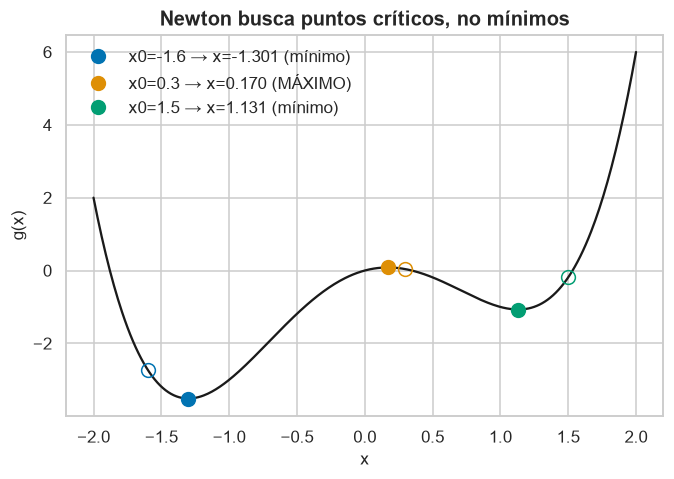

In [18]:
g_  = lambda x: x**4 - 3 * x**2 + x
dg  = lambda x: 4 * x**3 - 6 * x + 1
d2g = lambda x: 12 * x**2 - 6

fig, ax = plt.subplots()
xs = np.linspace(-2, 2, 400)
ax.plot(xs, g_(xs), color="k", lw=1.5)
for x0, c in zip([-1.6, 0.3, 1.5], colores):
    x_t = x0
    for _ in range(20):
        x_t = x_t - dg(x_t) / d2g(x_t)           # x - g'(x)/g''(x)
    tipo = "mínimo" if d2g(x_t) > 0 else "MÁXIMO"
    ax.plot(x0, g_(x0), "o", color=c, mfc="none", ms=9)
    ax.plot(x_t, g_(x_t), "o", color=c, ms=9, label=f"x0={x0} → x={x_t:.3f} ({tipo})")
ax.set(xlabel="x", ylabel="g(x)", title="Newton busca puntos críticos, no mínimos")
ax.legend(); plt.show()

Los círculos huecos son los arranques, los llenos donde terminó cada corrida. Desde $x_0 = 0.3$, donde $g'' < 0$, Newton fue derecho al **máximo** local. No es un error del método: es lo que hace. Por eso, para usarlo en la regresión logística, vamos a necesitar saber de antemano que la función tiene un único punto crítico, y que es el que queremos (§9).

Por último, la afirmación de "¿Por qué nos importa?": un paso de Newton sobre el $RSS$, desde un $\beta$ cualquiera, da la solución de cuadrados mínimos.

In [19]:
rng = np.random.default_rng(4)
Xn = np.c_[np.ones(100), rng.normal(size=(100, 3))]
yn = Xn @ np.array([1.0, -2.0, 0.5, 3.0]) + rng.normal(size=100)

beta_t = rng.normal(size=4) * 10                 # arranque arbitrario
grad = -2 * Xn.T @ (yn - Xn @ beta_t)            # gradiente del RSS (clase 2)
H = 2 * Xn.T @ Xn                                # Hessiano del RSS: no depende de beta
beta_1 = beta_t - np.linalg.solve(H, grad)       # resolver H d = grad en vez de invertir
print("Un paso de Newton:", beta_1)
print("lstsq:            ", np.linalg.lstsq(Xn, yn, rcond=None)[0])

Un paso de Newton: [ 0.8388 -1.9741  0.5161  2.8875]
lstsq:             [ 0.8388 -1.9741  0.5161  2.8875]


Iguales. El Hessiano del $RSS$ es $2\mathbf{X}^T\mathbf{X}$, constante, y la parábola de Taylor **es** la función.

##### 🏭 Así se hace en la industria

`scipy.optimize.minimize` tiene variantes de Newton. `Newton-CG` recibe el gradiente y el Hessiano y resuelve el sistema $\mathbf{H}\mathbf{d} = \nabla f$ de forma iterativa (gradientes conjugados), sin factorizar $\mathbf{H}$, lo que sirve cuando $p$ es grande. Sobre el mismo $RSS$:

In [20]:
from scipy.optimize import minimize

res = minimize(lambda b: np.sum((yn - Xn @ b) ** 2), x0=np.zeros(4), method="Newton-CG",
               jac=lambda b: -2 * Xn.T @ (yn - Xn @ b), hess=lambda b: 2 * Xn.T @ Xn)
print(res.x, "· iteraciones:", res.nit)

[ 0.8388 -1.9741  0.5161  2.8875] · iteraciones: 6


### ⚠️ Confusión típica

Creer que Newton "minimiza". Newton **anula el gradiente**. Si querés un mínimo, tenés que saber que el Hessiano es definido positivo en la zona donde estás (o en todos lados, si la función es convexa). Si querés un máximo, como en la log-verosimilitud de §8, lo que necesitás es que el Hessiano sea definido **negativo**, y la fórmula del paso es la misma: $\mathbf{x}_1 = \mathbf{x}_0 - \mathbf{H}^{-1}\nabla f$. No le cambies el signo "porque ahora maximizo"; el signo ya lo pone $\mathbf{H}$.

Segunda trampa: comparar costos mal. Newton converge en pocas iteraciones, pero cada una arma una matriz de $p \times p$ y resuelve un sistema, que cuesta del orden de $p^3$ operaciones. El descenso por gradiente hace muchas iteraciones baratas. Con $p$ chico gana Newton; con $p$ de millones (redes neuronales), Newton puro es impracticable.

## 7. Regresión logística: el modelo

📓 celdas 25–28 · 📕 ESL §4.4 · 📘 Bishop §4.3.2, §4.3.4

### La idea en criollo

En las apuestas no se habla de probabilidades, se habla de **momios**: "3 a 1" quiere decir que por cada vez que pasa, hay tres que no. Si la probabilidad es $p$, el momio (*odds*) es $p/(1-p)$. Una probabilidad vive entre 0 y 1; un momio vive entre 0 e infinito; y su **logaritmo** vive en toda la recta real, de $-\infty$ a $+\infty$.

Esa es la jugada. Una función lineal $\beta_0 + \beta^Tx$ puede dar cualquier número real. No sirve para modelar una probabilidad, que tiene techo y piso (era el problema de §1), pero encaja perfecto con el **logaritmo del momio**. Entonces no modelás $p$ de forma lineal: modelás $\log\frac{p}{1-p}$ de forma lineal, y después despejás $p$.

> **Dónde se rompe la analogía.** Un momio compara un resultado contra "todo lo demás". Con $K$ clases, la regresión logística compara cada clase contra **una clase de referencia** fija (la $K$), no contra el resto. La elección de cuál es la referencia es arbitraria y, como vamos a ver, no cambia las probabilidades que da el modelo.

### Formalizándolo

**Respuesta a la celda 25.** *"¿Hay alguna alternativa más adecuada?"* que la regresión sobre indicadoras. Sí: en lugar de pedirle a una función lineal que aproxime una probabilidad (y se salga de $[0, 1]$), se le pide que aproxime un **log-odds**, que no tiene restricciones de rango. Para $K$ clases, tomando la clase $K$ como referencia:

$$\log\frac{P(G = k \mid X = x)}{P(G = K \mid X = x)} = \beta_{k0} + \beta_k^Tx, \qquad k = 1, \ldots, K-1.$$

Son $K - 1$ ecuaciones (celda 26), cada una con su intercepto $\beta_{k0}$ y su vector $\beta_k \in \mathbb{R}^p$. Para no arrastrar la expresión entera, llamemos $\eta_k = \beta_{k0} + \beta_k^Tx$ (leelo "eta ka").

*¿Por qué $K - 1$ y no $K$?* Porque las $K$ probabilidades suman 1: si conocés $K - 1$ de ellas, la última está determinada. Si pusieras una función lineal también para la clase $K$, el modelo tendría parámetros de más: sumarle el mismo vector a todos los $\beta_k$ daría exactamente las mismas probabilidades, y no habría un único $\beta$ óptimo.

**El despeje (celda 27).** La clase da el resultado; hagamos la cuenta. Llamá $p_k = P(G = k \mid X = x)$. Exponenciando cada ecuación:

$$\frac{p_k}{p_K} = e^{\eta_k} \quad\Longrightarrow\quad p_k = p_K\,e^{\eta_k}, \qquad k = 1, \ldots, K-1.$$

Ahora usamos que todas suman 1:

$$1 = \sum_{k=1}^{K-1} p_k + p_K = p_K\sum_{l=1}^{K-1}e^{\eta_l} + p_K = p_K\Big(1 + \sum_{l=1}^{K-1}e^{\eta_l}\Big).$$

Despejando $p_K$ y volviendo a $p_k = p_K e^{\eta_k}$:

$$P(G = K \mid X = x) = \frac{1}{1 + \sum_{l=1}^{K-1}e^{\eta_l}}, \qquad P(G = k \mid X = x) = \frac{e^{\eta_k}}{1 + \sum_{l=1}^{K-1}e^{\eta_l}}.$$

Chequeo: todos los términos son positivos, así que cada $p_k$ está en $(0, 1)$, y por construcción suman 1. Ahora sí son probabilidades de verdad.

La clase agrupa todos los parámetros en $\theta = \{\beta_{10}, \beta_1^T, \ldots, \beta_{(K-1)0}, \beta_{K-1}^T\}$, que son $(K-1)(p+1)$ números, y escribe $p_k(x; \theta)$. El punto y coma se lee "como función de $x$, con parámetros $\theta$": separa la variable de entrada de lo que hay que estimar.

**El caso binario (celda 28).** Con $K = 2$ hay una sola ecuación, $\log\frac{p_1}{p_2} = \beta_{10} + \beta_1^Tx = \eta$, y las fórmulas de arriba quedan:

$$p_1(x; \theta) = \frac{e^{\eta}}{1 + e^{\eta}} = \frac{1}{1 + e^{-\eta}}.$$

El segundo paso divide numerador y denominador por $e^{\eta}$: $\frac{e^\eta / e^\eta}{1/e^\eta + e^\eta/e^\eta} = \frac{1}{e^{-\eta} + 1}$. Esa función, $\sigma(\eta) = \frac{1}{1 + e^{-\eta}}$, es la **sigmoide** o **logística**, y le da nombre al método. Y $p_2 = 1 - p_1 = \frac{1}{1 + e^{\eta}}$.

**Por qué es un clasificador lineal.** La regla de Bayes elige la clase de mayor probabilidad. En el caso binario, $p_1 > p_2$ si y solo si $p_1/p_2 > 1$, si y solo si $\eta > 0$. La frontera es $\beta_{10} + \beta_1^Tx = 0$: un hiperplano. Con $K$ clases, la frontera entre $k$ y $l$ es donde $\log(p_k/p_l) = \eta_k - \eta_l = 0$, que también es lineal en $x$ (restar dos log-odds contra la misma referencia cancela la referencia). Las probabilidades son no lineales en $x$; las fronteras, no.

### ¿Por qué nos importa?

Mirá la ecuación recuadrada de §3: en LDA, el log-cociente de posteriores **también** es $\beta_0 + \beta^Tx$. LDA y regresión logística producen el **mismo tipo** de modelo. La diferencia está en cómo llegan a los coeficientes:

- **LDA** supone que las $x$ de cada clase son normales con covarianza común, estima medias y covarianza, y los coeficientes salen como consecuencia ($\beta = \hat{\mathbf{\Sigma}}^{-1}(\hat\mu_k - \hat\mu_l)$).
- **Regresión logística** no dice nada sobre cómo se distribuyen las $x$. Supone solo que el log-odds es lineal, y estima los coeficientes directamente maximizando la verosimilitud de las etiquetas (§8).

La logística hace menos supuestos y es más robusta cuando las $x$ no son normales; LDA aprovecha más información cuando sí lo son. Esta comparación es 📕 ESL §4.4.5.

### En código

La sigmoide y las tres escalas: probabilidad, odds y log-odds.

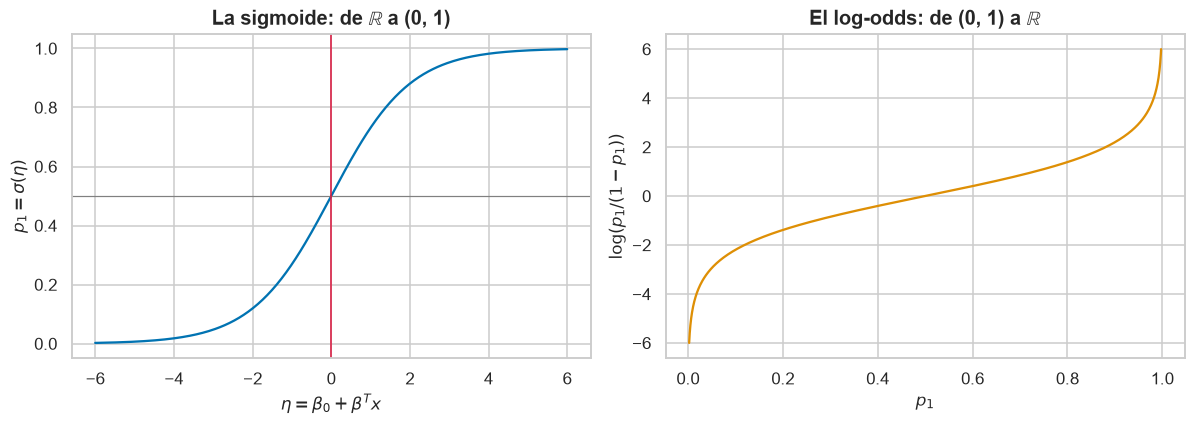

In [21]:
eta = np.linspace(-6, 6, 300)
p1 = 1 / (1 + np.exp(-eta))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(eta, p1, color=colores[0])
axes[0].axhline(0.5, color="gray", lw=0.8); axes[0].axvline(0, color="crimson", lw=1)
axes[0].set(xlabel=r"$\eta = \beta_0 + \beta^T x$", ylabel=r"$p_1 = \sigma(\eta)$", title=r"La sigmoide: de $\mathbb{R}$ a (0, 1)")
axes[1].plot(p1, np.log(p1 / (1 - p1)), color=colores[1])
axes[1].set(xlabel=r"$p_1$", ylabel=r"$\log(p_1 / (1 - p_1))$", title=r"El log-odds: de (0, 1) a $\mathbb{R}$")
plt.tight_layout(); plt.show()

Las dos curvas son inversas una de la otra: la de la derecha es la de la izquierda reflejada respecto de la diagonal. La línea roja marca $\eta = 0$, donde $p_1 = 1/2$: la frontera de decisión. Fijate en la forma de la sigmoide: es el "escalón suave" que en §1 la recta no podía imitar.

Ahora $K = 3$ con una sola variable. Elegimos coeficientes cualesquiera para las dos ecuaciones (la clase 3 es la referencia) y calculamos las probabilidades con las fórmulas del despeje.

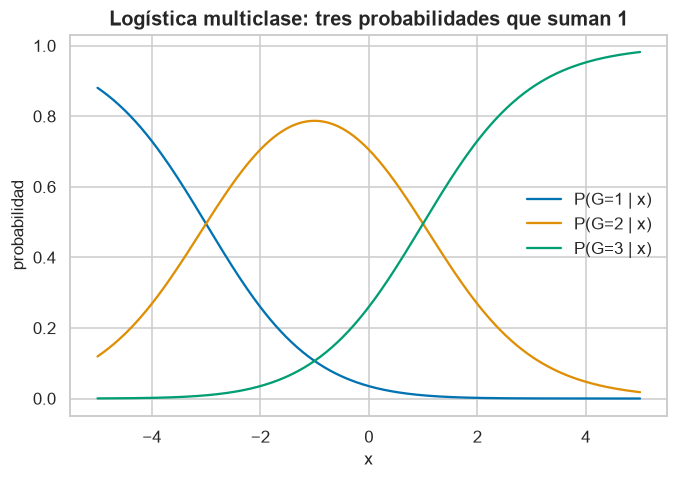

¿Suman 1? True · mín: 0.0 · máx: 0.982
Clases predichas a lo largo de x: [0 1 2]


In [22]:
x = np.linspace(-5, 5, 300)
etas = np.column_stack([-2.0 - 2.0 * x,          # η₁: clase 1 contra la 3
                        1.0 - 1.0 * x])          # η₂: clase 2 contra la 3
denom = 1 + np.exp(etas).sum(axis=1)
P = np.column_stack([np.exp(etas) / denom[:, None], 1 / denom])

fig, ax = plt.subplots()
for k in range(3):
    ax.plot(x, P[:, k], color=colores[k], label=f"P(G={k + 1} | x)")
ax.set(xlabel="x", ylabel="probabilidad", title="Logística multiclase: tres probabilidades que suman 1")
ax.legend(); plt.show()
print("¿Suman 1?", np.allclose(P.sum(1), 1), "· mín:", P.min().round(4), "· máx:", P.max().round(4))
print("Clases predichas a lo largo de x:", np.unique(P.argmax(1)))

Comparalo con el gráfico de masking de §1. Las tres curvas viven en $(0, 1)$, suman 1, y la clase del medio **gana una zona** en el centro (entre $x = -3$ y $x = 1$, donde $\eta_1 = \eta_2$ y donde $\eta_2 = 0$). Con estas probabilidades ninguna clase queda tapada por la forma del modelo: si los datos piden que la clase 2 gane en el medio, hay coeficientes que lo logran. Ojo, eso no quiere decir que la logística sea inmune a todo (sus fronteras siguen siendo lineales), pero no sufre el masking de las rectas sueltas de §1.

##### 🏭 Así se hace en la industria

Nadie escribe la sigmoide a mano: `scipy.special.expit` es la sigmoide y `scipy.special.softmax` la versión multiclase. `softmax` usa una parametrización **simétrica**, con $K$ funciones lineales y $p_k = e^{\eta_k}/\sum_{m=1}^{K} e^{\eta_m}$. Es la misma familia que la de la clase si fijás $\eta_K = 0$ para la referencia, porque $e^0 = 1$ es el "1 +" del denominador:

In [23]:
from scipy.special import expit, softmax

print("¿expit = sigmoide a mano?", np.allclose(expit(eta), p1))
P_sm = softmax(np.column_stack([etas, np.zeros(len(x))]), axis=1)   # η de la referencia = 0
print("¿softmax con η₃ = 0 = fórmula de la celda 27?", np.allclose(P_sm, P))

¿expit = sigmoide a mano? True
¿softmax con η₃ = 0 = fórmula de la celda 27? True


Es útil saberlo porque `sklearn`, en el caso multiclase, usa la versión simétrica: te devuelve $K$ vectores de coeficientes, no $K - 1$. La sobra de parámetros que mencionamos arriba la resuelve la regularización (§10), que elige una solución entre todas las equivalentes.

### ⚠️ Confusión típica

El nombre. "Regresión logística" es un método de **clasificación**. Se llama regresión porque es un modelo lineal para una función de $E(Y \mid X)$, en la familia de los modelos lineales generalizados, pero lo que produce es una probabilidad de clase y, con ella, una etiqueta.

Segunda trampa: decir que "la probabilidad es lineal en $x$". Lo lineal es el **log-odds**. La probabilidad es la sigmoide de algo lineal, y un cambio de una unidad en $x_j$ no suma una cantidad fija a la probabilidad: **multiplica el odds** por $e^{\beta_j}$. Cuánto cambia la probabilidad depende de dónde estés en la curva: mucho cerca de $p = 1/2$, casi nada cerca de 0 o de 1.

## 8. Máxima verosimilitud y el gradiente

📓 celdas 24, 29–32 · 📕 ESL §4.4.1 · 📘 Bishop §4.3.2

### La idea en criollo

Tenés las etiquetas que pasaron y un modelo con una perilla $\beta$. Para cada posición de la perilla, el modelo te dice qué tan probable era ver **exactamente** esas etiquetas. Máxima verosimilitud elige la posición que hace a lo observado lo más probable posible. Es la lógica de un detective: entre todas las explicaciones, quedate con la que hace menos sorprendente lo que viste.

Ya la usaste en la clase 3: con errores normales, máxima verosimilitud daba cuadrados mínimos. Acá las etiquetas no son normales, son categóricas, y la cuenta cambia.

> **Dónde se rompe la analogía.** Un detective sensato desconfía de una explicación que encaja *demasiado* perfecto. Máxima verosimilitud no: si existe un $\beta$ que hace a lo observado casi seguro, lo va a buscar, aunque haya que llevarlo al infinito. Ese es exactamente el problema de los datos separables, en §9 y §10.

### Formalizándolo

**La multinomial (celda 24).** Si hacés $n$ ensayos independientes, cada uno cae en una de $k$ categorías con probabilidades $p_1, \ldots, p_k$, y contás cuántos cayeron en cada una ($x_1, \ldots, x_k$, con $\sum x_i = n$):

$$P(X_1 = x_1, \ldots, X_k = x_k) = \frac{n!}{x_1!\cdots x_k!}\,p_1^{x_1}\cdots p_k^{x_k}.$$

El factor $p_1^{x_1}\cdots p_k^{x_k}$ es la probabilidad de **una** secuencia concreta con esos conteos; el coeficiente $\frac{n!}{x_1!\cdots x_k!}$ cuenta cuántas secuencias distintas dan los mismos conteos.

La clase no lo dice, pero lo que se usa en la logística es el caso **$n = 1$**: cada observación es **un solo** ensayo. Con $n = 1$, exactamente un $x_j$ vale 1 (la clase que salió) y los demás valen 0. El coeficiente vale $\frac{1!}{1!\,0!\cdots 0!} = 1$, y todos los factores $p_m^0 = 1$ desaparecen salvo uno:

$$P = p_1^{0}\cdots p_j^{1}\cdots p_k^{0} = p_j.$$

La probabilidad de la observación es la probabilidad de la clase que salió. Cuando $n = 1$ a esta distribución se la llama **categórica**, y con dos clases es la **Bernoulli**. Esa es la respuesta a *"¿Cuál es la distribución más apropiada?"* (celda 29).

**La verosimilitud (celda 29).** Las $N$ observaciones son independientes, así que la probabilidad conjunta de las etiquetas es el producto. Fijate que es **condicional a las $x$**: no modelamos de dónde salen las $x$, solo las etiquetas dadas las $x$. Por eso la logística es discriminativa.

$$\mathcal{L}(\theta) = \prod_{i=1}^N P(G = g_i \mid X = x_i) = \prod_{i=1}^N p_{g_i}(x_i; \theta).$$

El subíndice $g_i$ quiere decir "la probabilidad que el modelo le asigna a la clase **que efectivamente tiene** la observación $i$". Tomando logaritmo (el producto pasa a suma, y como $\log$ es creciente el máximo no se mueve):

$$\ell(\theta) = \sum_{i=1}^N \log p_{g_i}(x_i; \theta).$$

Además de ser más cómodo para derivar, el logaritmo evita un problema numérico: el producto de miles de números menores que 1 se vuelve cero en la computadora.

**El caso binario (celda 30).** Codificamos $y_i = 1$ si $g_i = 1$ e $y_i = 0$ si $g_i = 2$, y escribimos $p(x_i; \beta) = p_1(x_i; \theta)$. Entonces

$$\ell(\beta) = \sum_{i=1}^N \Big\{ y_i\log p(x_i; \beta) + (1 - y_i)\log\big(1 - p(x_i; \beta)\big)\Big\}.$$

*"De esta forma se cubren los dos casos"*: si $y_i = 1$ el segundo término se anula y queda $\log p$; si $y_i = 0$ se anula el primero y queda $\log(1 - p)$. Es la Bernoulli $p^{y}(1-p)^{1-y}$ con logaritmo.

**Un cambio de notación que la clase hace al pasar.** Desde la celda 30, $x_i$ incluye un 1 adelante y $\beta$ incluye al intercepto: $x_i = (1, x_{i1}, \ldots, x_{ip})^T$ y $\beta = (\beta_0, \beta_1, \ldots, \beta_p)^T$, ambos en $\mathbb{R}^{p+1}$. Así $\beta_{10} + \beta_1^Tx$ se escribe $\beta^Tx_i$. Es la misma convención de la matriz de diseño de la clase 2. Llamemos $\eta_i = \beta^Tx_i$.

**La simplificación.** Con $p_i = \frac{e^{\eta_i}}{1 + e^{\eta_i}}$ y $1 - p_i = \frac{1}{1 + e^{\eta_i}}$, usando $\log(a/b) = \log a - \log b$ y $\log e^{\eta} = \eta$:

$$\log p_i = \eta_i - \log(1 + e^{\eta_i}), \qquad \log(1 - p_i) = -\log(1 + e^{\eta_i}).$$

Reemplazando:

$$y_i\big(\eta_i - \log(1 + e^{\eta_i})\big) + (1 - y_i)\big(-\log(1 + e^{\eta_i})\big) = y_i\eta_i - \underbrace{(y_i + 1 - y_i)}_{=\,1}\log(1 + e^{\eta_i}).$$

$$\boxed{\ell(\beta) = \sum_{i=1}^N\Big\{y_i\,\beta^Tx_i - \log\big(1 + e^{\beta^Tx_i}\big)\Big\}}$$

**El gradiente (celda 31).** Derivamos término a término respecto del vector $\beta$. Para el primero, la regla $\partial(a^T\beta)/\partial\beta = a$ de la clase 2:

$$\frac{\partial}{\partial\beta}\big(y_i\,\beta^Tx_i\big) = y_i\,x_i.$$

Para el segundo, regla de la cadena: la derivada de $\log(1 + e^{\eta})$ respecto de $\eta$ es $\frac{e^{\eta}}{1 + e^{\eta}} = p$, y la de $\eta = \beta^Tx_i$ respecto de $\beta$ es $x_i$:

$$\frac{\partial}{\partial\beta}\log\big(1 + e^{\beta^Tx_i}\big) = \frac{e^{\beta^Tx_i}}{1 + e^{\beta^Tx_i}}\,x_i = p(x_i; \beta)\,x_i.$$

Restando y sumando sobre $i$:

$$\frac{\partial\ell(\beta)}{\partial\beta} = \sum_{i=1}^N x_i\big(y_i - p(x_i; \beta)\big).$$

Cada observación aporta su vector $x_i$ multiplicado por **cuánto se equivocó** el modelo en ella: $y_i - p_i$, que es positivo si la etiqueta era 1 y el modelo le daba poca probabilidad.

**Comparalo con la clase 2.** La ecuación normal de cuadrados mínimos se puede escribir $\sum_i x_i(y_i - x_i^T\beta) = 0$. Acá es $\sum_i x_i(y_i - p_i) = 0$: misma estructura, con la predicción lineal $x_i^T\beta$ reemplazada por la probabilidad $p_i$. La diferencia es que $p_i = \sigma(\beta^Tx_i)$ es **no lineal** en $\beta$, y por eso no se puede despejar: no hay solución cerrada.

**Las ecuaciones una por una (celda 32).** La primera componente de $x_i$ es el 1 del intercepto, así que la primera ecuación es

$$\sum_{i=1}^N(y_i - p_i) = 0 \quad\Longleftrightarrow\quad \sum_{i=1}^N y_i = \sum_{i=1}^N p_i.$$

A la izquierda, cuántas observaciones de la clase 1 hay. A la derecha, cuántas **espera** el modelo, sumando sus probabilidades. En el óptimo coinciden: el modelo queda **calibrado en el total**. Las demás, $\sum_i x_{ij}y_i = \sum_i x_{ij}p_i$, piden lo mismo para cada variable: la suma de $x_j$ entre las observaciones de la clase 1 tiene que ser igual a la suma de $x_j$ ponderada por la probabilidad que el modelo le da a la clase 1.

### ¿Por qué nos importa?

Porque esta función, cambiada de signo, es la **pérdida logarítmica** (*log-loss* o *entropía cruzada binaria*): lo que minimizan `sklearn` y cualquier red neuronal que clasifica. La vas a ver en toda la materia. Y porque el gradiente tiene la forma "variables por error", la misma que en cuadrados mínimos; esa coincidencia es la que en §9 hace que cada paso de Newton sea un problema de cuadrados mínimos.

### En código

Datos binarios generados con un modelo logístico conocido, $\beta_{\text{verdadero}} = (-0.5, 2, -1)$. Primero comprobamos que la forma original de $\ell$ y la simplificada son iguales, y que el gradiente analítico coincide con uno numérico por diferencias finitas.

In [24]:
rng = np.random.default_rng(5)
N = 300
Xl = np.c_[np.ones(N), rng.normal(size=(N, 2))]          # con la columna de unos: x_i en R^{p+1}
beta_v = np.array([-0.5, 2.0, -1.0])
yl = (rng.uniform(size=N) < 1 / (1 + np.exp(-Xl @ beta_v))).astype(float)

def loglik(b):
    eta = Xl @ b
    return np.sum(yl * eta - np.log1p(np.exp(eta)))      # la forma recuadrada

def loglik_original(b):
    p = 1 / (1 + np.exp(-Xl @ b))
    return np.sum(yl * np.log(p) + (1 - yl) * np.log(1 - p))

def gradiente(b):
    p = 1 / (1 + np.exp(-Xl @ b))
    return Xl.T @ (yl - p)                               # sum_i x_i (y_i - p_i)

b0 = np.array([0.3, -0.2, 0.5])
eps = 1e-6
grad_num = np.array([(loglik(b0 + eps * e) - loglik(b0 - eps * e)) / (2 * eps) for e in np.eye(3)])
print("¿Las dos formas de ℓ coinciden?", np.isclose(loglik(b0), loglik_original(b0)))
print("Gradiente analítico:", gradiente(b0))
print("Gradiente numérico: ", grad_num)

¿Las dos formas de ℓ coinciden? True
Gradiente analítico: [-41.5115  98.7155 -78.4051]
Gradiente numérico:  [-41.5115  98.7155 -78.4051]


Coinciden. `Xl.T @ (yl - p)` es la suma $\sum_i x_i(y_i - p_i)$ escrita como producto de matrices: lo formalizamos en §9.

Ahora miramos la forma de $\ell$. Para poder dibujarla fijamos $\beta_2$ en su valor verdadero y barremos $\beta_0$ y $\beta_1$.

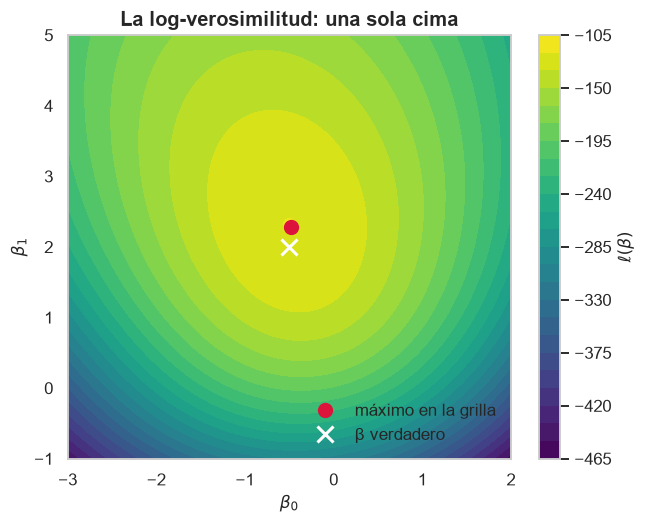

In [25]:
b0s, b1s = np.meshgrid(np.linspace(-3, 2, 120), np.linspace(-1, 5, 120))
L = np.array([loglik(np.array([a, b, beta_v[2]])) for a, b in zip(b0s.ravel(), b1s.ravel())]).reshape(b0s.shape)

fig, ax = plt.subplots(figsize=(6.5, 5))
cs = ax.contourf(b0s, b1s, L, levels=30, cmap="viridis")
fig.colorbar(cs, ax=ax, label=r"$\ell(\beta)$")
i_max = np.unravel_index(L.argmax(), L.shape)
ax.plot(b0s[i_max], b1s[i_max], "o", color="crimson", ms=9, label="máximo en la grilla")
ax.plot(beta_v[0], beta_v[1], "x", color="white", ms=10, mew=2, label="β verdadero")
ax.set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$", title="La log-verosimilitud: una sola cima"); ax.legend(loc="lower right")
plt.show()

Un único pico, con curvas de nivel que lo rodean como una loma: no hay mínimos locales ni otras cimas. Eso es la **concavidad** de $\ell$, que demostramos en §9. El máximo queda cerca del $\beta$ verdadero, pero no encima: es una estimación con $N = 300$ datos.

##### 🏭 Así se hace en la industria

Para ver las ecuaciones de la celda 32 en el óptimo, necesitamos el $\hat\beta$ de máxima verosimilitud. Se lo pedimos a `sklearn` **sin penalización** (`C=np.inf`; por defecto `sklearn` regulariza, ver §10). Con ese $\hat\beta$, el gradiente tiene que dar cero y la suma de probabilidades tiene que igualar la cantidad de unos.

In [26]:
from sklearn.linear_model import LogisticRegression

mod = LogisticRegression(C=np.inf, tol=1e-10, max_iter=1000).fit(Xl[:, 1:], yl)   # sklearn pone su propio intercepto
beta_hat = np.r_[mod.intercept_, mod.coef_.ravel()]
p_hat = mod.predict_proba(Xl[:, 1:])[:, 1]
print("β̂ =", beta_hat, "  (verdadero:", beta_v, ")")
print("Gradiente en β̂:", gradiente(beta_hat))
print(f"Σ y_i = {yl.sum():.0f}   ·   Σ p̂_i = {p_hat.sum():.4f}")

β̂ = [-0.5129  2.3727 -1.1433]   (verdadero: [-0.5  2.  -1. ] )
Gradiente en β̂: [-0. -0. -0.]
Σ y_i = 129   ·   Σ p̂_i = 129.0000


El gradiente queda prácticamente en cero (del orden de la tolerancia del optimizador) y la cantidad esperada de unos coincide con la observada: la primera ecuación de la celda 32, cumplida. Escribir vos el algoritmo que llega a ese $\hat\beta$ es el Ejercicio 4.

### ⚠️ Confusión típica

Olvidarse de que $x_i$ ahora tiene un 1 adelante. Si armás el gradiente con las $x$ sin la columna de unos, te falta la ecuación del intercepto, y el modelo no queda calibrado. En el código de arriba fijate que `Xl` tiene la columna de unos y que a `sklearn` le pasamos `Xl[:, 1:]`, porque `sklearn` agrega su propio intercepto. Mezclar las dos convenciones es el error más común al comparar implementaciones.

Segunda trampa: pensar que "derivada igual a cero" ya garantiza un máximo. Garantiza un punto crítico (§6). Que sea **el** máximo, y único, sale de la concavidad, que se prueba con el Hessiano en §9.

### ❓ La pregunta que quedó abierta

La celda 31 pregunta *"¿Cuántas ecuaciones son? ¿Qué es la derivada en este caso?"* y la celda 32 contesta solo la primera. Completo:

- **La derivada** de una función de $\mathbb{R}^{p+1}$ en $\mathbb{R}$ es el **gradiente**: un vector de $p + 1$ componentes, la derivada parcial de $\ell$ respecto de cada $\beta_j$. La notación $\partial\ell/\partial\beta$ es ese vector.
- **Igualarla a cero** son entonces $p + 1$ ecuaciones escalares, una por componente: la del intercepto y una por variable. Son **no lineales** en $\beta$ porque $\beta$ aparece adentro de la sigmoide, y por eso no se resuelven despejando sino con un método iterativo. Ese es el puente a Newton-Raphson en §9.

## 9. Newton aplicado a la logística: Hessiano e IRLS

📓 celdas 33–36 · 📕 ESL §4.4.1 · 📘 Bishop §4.3.3

### La idea en criollo

Pensá en un profesor que prepara un repaso antes del examen. No le dedica tiempo al alumno que va a aprobar seguro ni al que va a desaprobar seguro: se lo dedica a los que están **en el límite**, porque ahí es donde un poco de trabajo cambia el resultado.

IRLS hace eso con las observaciones. En cada paso, cada observación recibe un peso $p_i(1 - p_i)$, que es máximo ($1/4$) cuando el modelo le da $p_i = 1/2$ (la duda total) y casi cero cuando le da $p_i \approx 0$ o $p_i \approx 1$ (está seguro). Con esos pesos resuelve un cuadrados mínimos ponderado, recalcula las probabilidades, recalcula los pesos, y repite.

> **Dónde se rompe la analogía.** El profesor sabe quién va a aprobar. El modelo no: el peso se calcula con **lo que el modelo cree**, no con la etiqueta verdadera. Una observación que el modelo da por segura y está **mal** clasificada ($p_i \approx 0.99$ con $y_i = 0$) recibe peso chico, pero no queda ignorada: su "respuesta ajustada" $z_i$, que vamos a definir abajo, se vuelve enorme y la sigue haciendo pesar.

### Formalizándolo

**El Hessiano (celda 33).** Derivamos el gradiente $\sum_i x_i(y_i - p_i)$ otra vez, ahora respecto de $\beta^T$ (así el resultado es una matriz). $x_i$ e $y_i$ no dependen de $\beta$; solo $p_i$:

$$\frac{\partial^2\ell}{\partial\beta\,\partial\beta^T} = -\sum_{i=1}^N x_i\,\frac{\partial p_i}{\partial\beta^T}.$$

Para $\partial p_i/\partial\beta^T$ hace falta la derivada de la sigmoide. Con $\sigma(\eta) = (1 + e^{-\eta})^{-1}$:

$$\sigma'(\eta) = \frac{e^{-\eta}}{(1 + e^{-\eta})^2} = \underbrace{\frac{1}{1 + e^{-\eta}}}_{\sigma(\eta)}\cdot\underbrace{\frac{e^{-\eta}}{1 + e^{-\eta}}}_{1 - \sigma(\eta)}.$$

(El segundo factor es $1 - \sigma$ porque $1 - \frac{1}{1 + e^{-\eta}} = \frac{e^{-\eta}}{1 + e^{-\eta}}$.) Por regla de la cadena, con $\partial\eta_i/\partial\beta^T = x_i^T$:

$$\frac{\partial p_i}{\partial\beta^T} = p_i(1 - p_i)\,x_i^T \quad\Longrightarrow\quad \mathbf{H} = -\sum_{i=1}^N x_i x_i^T\,p_i(1 - p_i).$$

**Respuesta a la celda 33:** *"¿Qué es $x_ix_i^T$?"*. Es el **producto exterior**: columna de $(p+1) \times 1$ por fila de $1 \times (p+1)$, una matriz de $(p+1) \times (p+1)$ con entrada $(j, l)$ igual a $x_{ij}x_{il}$. No confundir con $x_i^Tx_i$, el producto interno, que es un número. $\mathbf{H}$ es una suma de $N$ de estas matrices, cada una pesada por $p_i(1 - p_i)$.

**El paso que falta: es un máximo, y único.** La clase iguala el gradiente a cero y aplica Newton sin decir por qué el punto crítico es el máximo. Para cualquier vector $v \in \mathbb{R}^{p+1}$:

$$v^T\mathbf{H}v = -\sum_{i=1}^N p_i(1 - p_i)\,v^Tx_ix_i^Tv = -\sum_{i=1}^N p_i(1 - p_i)\,(x_i^Tv)^2 \le 0,$$

porque $p_i(1 - p_i) > 0$ y un cuadrado es $\ge 0$. El Hessiano es **semidefinido negativo** en todo punto, así que $\ell$ es **cóncava**: cualquier punto crítico es un máximo global. Si además $\mathbf{X}$ tiene rango columna completo, $x_i^Tv$ no puede ser cero para todo $i$ con $v \ne 0$, la desigualdad es estricta, y el máximo, si existe, es **único**. Esto es lo que en §6 dijimos que íbamos a necesitar: con $\ell$ cóncava, Newton no puede caer en un mínimo ni en una silla, porque no los hay.

**La actualización.** Newton (§6) es $\beta^{\text{new}} = \beta^{\text{old}} - \mathbf{H}^{-1}\nabla\ell$, con todo evaluado en $\beta^{\text{old}}$.

**Forma matricial (celdas 34–35).** Con $\mathbf{y}$ el vector de etiquetas, $\mathbf{X}$ la matriz de diseño de $N \times (p+1)$ (fila $i$ = $x_i^T$), $\mathbf{p}$ el vector de las $p_i$ y $\mathbf{W} = \text{diag}\big(p_1(1-p_1), \ldots, p_N(1-p_N)\big)$:

- $\mathbf{X}^T(\mathbf{y} - \mathbf{p}) = \sum_i x_i(y_i - p_i)$, porque la columna $i$ de $\mathbf{X}^T$ es $x_i$, y multiplicar una matriz por un vector es combinar sus columnas con los coeficientes del vector.
- $\mathbf{X}^T\mathbf{W}\mathbf{X} = \sum_i W_{ii}\,x_ix_i^T$, por la misma razón: como $\mathbf{W}$ es diagonal, $\mathbf{W}\mathbf{X}$ multiplica la fila $i$ de $\mathbf{X}$ por $W_{ii}$, y $\mathbf{X}^T\mathbf{A}$ con $\mathbf{A}$ de filas $a_i^T$ es $\sum_i x_ia_i^T$.

Entonces $\nabla\ell = \mathbf{X}^T(\mathbf{y} - \mathbf{p})$, $\mathbf{H} = -\mathbf{X}^T\mathbf{W}\mathbf{X}$, y los dos signos menos se cancelan:

$$\beta^{\text{new}} = \beta^{\text{old}} + (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{y} - \mathbf{p}).$$

**IRLS (celda 36).** La clase *"complica las cosas un poco más"*, y el resultado vale la pena. Paso a paso:

1. Escribimos $\beta^{\text{old}}$ como $\mathbf{I}\,\beta^{\text{old}}$, y la identidad como $(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}(\mathbf{X}^T\mathbf{W}\mathbf{X})$. Es multiplicar por 1:

$$\beta^{\text{new}} = (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{X}\,\beta^{\text{old}} + (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{y} - \mathbf{p}).$$

2. Sacamos $(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T$ como factor común por la izquierda:

$$\beta^{\text{new}} = (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\big[\mathbf{W}\mathbf{X}\beta^{\text{old}} + (\mathbf{y} - \mathbf{p})\big].$$

3. Para sacar también $\mathbf{W}$, escribimos $(\mathbf{y} - \mathbf{p}) = \mathbf{W}\mathbf{W}^{-1}(\mathbf{y} - \mathbf{p})$. Esto **requiere que $\mathbf{W}$ sea invertible**, o sea, $p_i(1 - p_i) > 0$ para todo $i$:

$$\beta^{\text{new}} = (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\big[\mathbf{X}\beta^{\text{old}} + \mathbf{W}^{-1}(\mathbf{y} - \mathbf{p})\big] = (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{z}.$$

El vector $\mathbf{z}$ se llama **respuesta ajustada** (*adjusted response*). Componente a componente:

$$z_i = x_i^T\beta^{\text{old}} + \frac{y_i - p_i}{p_i(1 - p_i)}.$$

¿De dónde sale esa expresión? Es la linealización del log-odds. La derivada de $\text{logit}(p) = \log\frac{p}{1-p}$ es $\frac{1}{p(1-p)}$, así que, por Taylor de primer orden alrededor de $p_i$, $\text{logit}(y_i) \approx \text{logit}(p_i) + \frac{y_i - p_i}{p_i(1-p_i)}$, y $\text{logit}(p_i) = x_i^T\beta^{\text{old}}$. $z_i$ es "el log-odds que habría que ajustar para acercarse a la etiqueta $y_i$", en la escala donde el modelo es lineal.

4. *"¡Es la solución de un problema de mínimos cuadrados ponderados!"* Verifiquémoslo. Si minimizás $(\mathbf{z} - \mathbf{X}\beta)^T\mathbf{W}(\mathbf{z} - \mathbf{X}\beta)$, derivando igual que en la clase 2 (con $\mathbf{W}$ simétrica) y anulando:

$$-2\mathbf{X}^T\mathbf{W}(\mathbf{z} - \mathbf{X}\beta) = 0 \quad\Longleftrightarrow\quad \mathbf{X}^T\mathbf{W}\mathbf{X}\,\beta = \mathbf{X}^T\mathbf{W}\mathbf{z},$$

que es la ecuación normal **ponderada**, y su solución es la de arriba. Cada paso de Newton es: regresar $\mathbf{z}$ sobre $\mathbf{X}$ dándole a la observación $i$ el peso $W_{ii}$. Como $\mathbf{z}$ y $\mathbf{W}$ cambian con $\beta$, se repite: *Iteratively Reweighted Least Squares*.

**Arranque.** ESL §4.4.1 propone $\beta = 0$. Ahí todas las $p_i = 1/2$, todos los pesos valen $1/4$, y el primer paso es un cuadrados mínimos común sobre $z_i = 4(y_i - 1/2) = \pm 2$.

### ¿Por qué nos importa?

Por lo que dice la propia celda 36, y vale entenderlo:

- **Hereda la maquinaria de cuadrados mínimos.** Cada paso es un `lstsq` ponderado, y todo lo que aprendiste en las clases 2 y 3 (no invertir, usar QR o SVD, el problema del mal condicionamiento) aplica tal cual.
- **Es general.** Cambiando la sigmoide por otra función de enlace y la Bernoulli por otra distribución (Poisson para conteos, por ejemplo), el mismo esquema ajusta cualquier modelo lineal generalizado (GLM). Solo cambian las fórmulas de $\mathbf{z}$ y $\mathbf{W}$.

### En código

Comprobamos con los datos de §8 las afirmaciones de esta sección, sin escribir el algoritmo completo (eso es el Ejercicio 4): que la suma de productos exteriores es $-\mathbf{X}^T\mathbf{W}\mathbf{X}$, que el Hessiano es definido negativo, y que el $\hat\beta$ de máxima verosimilitud es un **punto fijo** de la iteración IRLS.

In [27]:
def piezas(b):
    p = 1 / (1 + np.exp(-Xl @ b))
    return p, np.diag(p * (1 - p))

b_cualquiera = np.array([1.0, -0.5, 0.3])
p, W = piezas(b_cualquiera)
H_suma = -sum(np.outer(xi, xi) * pi_ * (1 - pi_) for xi, pi_ in zip(Xl, p))   # versión celda 33
H_matriz = -Xl.T @ W @ Xl                                                     # versión celda 35
print("¿Suma de productos exteriores = -XᵀWX?", np.allclose(H_suma, H_matriz))
print("Autovalores del Hessiano (todos negativos ⇒ cóncava):", np.linalg.eigvalsh(H_matriz))

# En el óptimo, un paso de IRLS no se mueve: beta_hat es punto fijo
p, W = piezas(beta_hat)
z = Xl @ beta_hat + (yl - p) / (p * (1 - p))
paso = np.linalg.solve(Xl.T @ W @ Xl, Xl.T @ W @ z)
print("β̂ (sklearn):          ", beta_hat)
print("un paso IRLS desde β̂: ", paso)

¿Suma de productos exteriores = -XᵀWX? True
Autovalores del Hessiano (todos negativos ⇒ cóncava): [-67.0734 -52.7261 -41.282 ]
β̂ (sklearn):           [-0.5129  2.3727 -1.1433]
un paso IRLS desde β̂:  [-0.5129  2.3727 -1.1433]


Los tres autovalores son negativos, y un paso de IRLS desde el óptimo devuelve el mismo $\hat\beta$: ahí $\mathbf{X}^T(\mathbf{y} - \mathbf{p}) = 0$ y la corrección es nula. Fijate que `np.linalg.solve` resuelve la ecuación normal ponderada sin invertir $\mathbf{X}^T\mathbf{W}\mathbf{X}$.

Ahora los pesos. ¿Qué observaciones manda IRLS al frente?

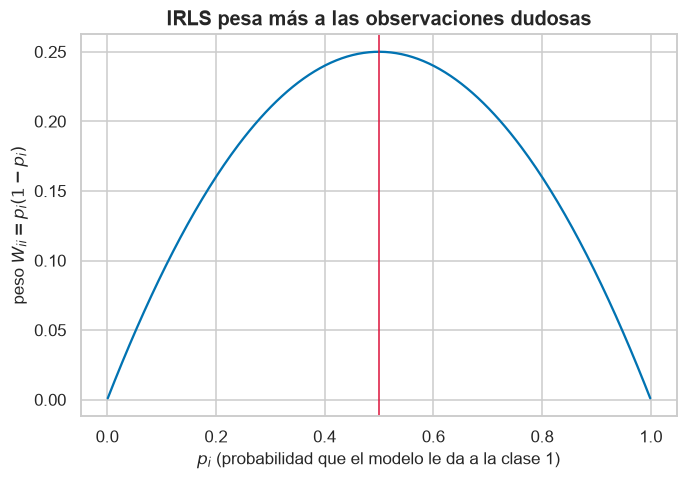

In [28]:
p_grid = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots()
ax.plot(p_grid, p_grid * (1 - p_grid), color=colores[0])
ax.axvline(0.5, color="crimson", lw=1)
ax.set(xlabel=r"$p_i$ (probabilidad que el modelo le da a la clase 1)", ylabel=r"peso $W_{ii} = p_i(1 - p_i)$",
       title="IRLS pesa más a las observaciones dudosas")
plt.show()

El peso es máximo, $1/4$, en $p_i = 1/2$, y cae a cero en los extremos. Eso conecta con la pregunta de la celda 33, y lo que pasa cuando **todos** los pesos se van a cero se ve con datos separables:

In [29]:
rng = np.random.default_rng(6)
Xsep = np.c_[np.ones(40), np.r_[rng.uniform(-3, -0.5, 20), rng.uniform(0.5, 3, 20)]]
ysep = np.r_[np.zeros(20), np.ones(20)]          # x < 0 ⇒ clase 0, x > 0 ⇒ clase 1: separables

def loglik_sep(b):
    eta = Xsep @ b
    return np.sum(ysep * eta - np.log1p(np.exp(eta)))

for t in [1, 5, 25, 125]:
    b = np.array([0.0, float(t)])                # la misma frontera (x = 0), cada vez más empinada
    p = 1 / (1 + np.exp(-Xsep @ b))
    print(f"β₁={t:>4}  ℓ={loglik_sep(b):10.6f}   peso máximo={np.max(p * (1 - p)):.2e}")

β₁=   1  ℓ= -7.766126   peso máximo=2.33e-01
β₁=   5  ℓ= -0.240743   peso máximo=6.13e-02
β₁=  25  ℓ= -0.000003   peso máximo=1.70e-06
β₁= 125  ℓ= -0.000000   peso máximo=1.42e-29


Con datos separables, empinar la sigmoide sin mover la frontera **siempre** mejora $\ell$, que se acerca a $0$ (su cota superior, porque es una suma de logaritmos de probabilidades) sin alcanzarlo nunca. No existe el máximo: $\hat\beta$ se va a infinito. Y mientras tanto los pesos colapsan a cero, $\mathbf{X}^T\mathbf{W}\mathbf{X}$ se vuelve casi singular y $\mathbf{W}^{-1}$ explota en la fórmula de $\mathbf{z}$.

##### 🏭 Así se hace en la industria

`statsmodels` ajusta la logística como un GLM con familia binomial, y su método por defecto es IRLS. Guarda la historia de las iteraciones:

In [30]:
import statsmodels.api as sm

glm = sm.GLM(yl, Xl, family=sm.families.Binomial()).fit()
print("β̂ statsmodels:", glm.params, "· iteraciones:", glm.fit_history["iteration"])
print("¿Coincide con sklearn sin penalizar?", np.allclose(glm.params, beta_hat, atol=1e-5))
for t, b in enumerate(glm.fit_history["params"][2:], start=1):
    print(f"  iteración {t}: {b}")

β̂ statsmodels: [-0.5129  2.3727 -1.1433] · iteraciones: 6
¿Coincide con sklearn sin penalizar? True
  iteración 1: [-0.3054  1.4177 -0.7074]
  iteración 2: [-0.4455  2.0492 -0.9939]
  iteración 3: [-0.5045  2.3316 -1.124 ]
  iteración 4: [-0.5128  2.372  -1.143 ]
  iteración 5: [-0.5129  2.3727 -1.1433]
  iteración 6: [-0.5129  2.3727 -1.1433]


Coincide con el $\hat\beta$ de `sklearn`, y converge en un puñado de iteraciones. Mirá cómo se estabilizan los decimales en la historia: la convergencia cuadrática de §6 otra vez. `statsmodels` arranca desde las probabilidades $(y_i + 1/2)/2$ en lugar de $\beta = 0$, así que su primera iteración no va a coincidir con la tuya si arrancás de cero; las siguientes se acercan igual al mismo $\hat\beta$. Esta historia es una buena referencia para chequear el Ejercicio 4. `sklearn`, en cambio, usa por defecto L-BFGS, un método que aproxima el Hessiano en lugar de calcularlo.

### ⚠️ Confusión típica

Equivocarse el signo al pasar de Newton a la forma matricial. Newton es $\beta - \mathbf{H}^{-1}\nabla\ell$, y como $\mathbf{H} = -\mathbf{X}^T\mathbf{W}\mathbf{X}$, el paso queda con **más**: $\beta + (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{y} - \mathbf{p})$. Si ponés menos, te alejás del máximo y $\ell$ baja en cada iteración. Un buen control: imprimí $\ell$ en cada paso; tiene que **subir**.

Segunda trampa: calcular $\mathbf{W}$ como matriz de $N \times N$. Con $N = 100\,000$ son $10^{10}$ números casi todos cero. Como es diagonal, alcanza con el vector de pesos: `X.T @ (w[:, None] * X)` en lugar de `X.T @ np.diag(w) @ X`.

### ❓ La pregunta que quedó abierta

La celda 33 pregunta *"Con el ojo ya entrenado, ¿dónde pueden aparecer problemas?"* y la clase pasa a la forma matricial. Los problemas son cuatro:

1. **$\mathbf{X}^T\mathbf{W}\mathbf{X}$ singular por las variables.** Igual que $\mathbf{X}^T\mathbf{X}$ en la clase 2: si hay columnas colineales o más variables que observaciones, no hay inversa y no hay un único $\hat\beta$.
2. **Datos separables.** Es el que viste en el código: el máximo no existe, los pesos van a cero y el algoritmo diverge. Pasa más de lo que parece cuando $p$ es grande respecto de $N$. La regularización de §10 lo arregla.
3. **Newton no tiene convergencia garantizada.** Aunque $\ell$ es cóncava, un paso completo puede pasarse del máximo. Es raro desde $\beta = 0$, pero ESL §4.4.1 menciona el remedio: si $\ell$ baja, achicar el paso a la mitad hasta que suba.
4. **Costo.** Cada iteración arma y resuelve un sistema de $(p+1) \times (p+1)$. Con miles de variables, se prefieren métodos que no forman el Hessiano.

Y una promesa que quedó sin cumplir: la celda 30 dice *"luego mencionaremos algunas estrategias para el caso general"* ($K > 2$) y nunca vuelve. Las tres habituales:

- **Newton multinomial directo.** El vector de parámetros tiene $(K-1)(p+1)$ componentes y el Hessiano es una matriz por bloques que acopla las clases. ESL §4.4.1 comenta que se puede seguir escribiendo como un IRLS, pero con una respuesta **vectorial** de $K-1$ componentes por observación y una matriz de pesos que deja de ser diagonal: ya no es el cuadrados mínimos ponderado simple del caso binario.
- **Uno contra el resto.** $K$ regresiones logísticas binarias, cada clase contra todas las demás. Es simple, pero las probabilidades resultantes no suman 1 y hay que normalizarlas.
- **Métodos de gradiente** (L-BFGS, descenso por gradiente estocástico) sobre la verosimilitud multinomial con la parametrización *softmax* de §7. Es lo que hace `sklearn` por defecto.

## 10. Regresión logística regularizada

📓 celda 37 · 📕 ESL §4.4.4 (L1) · 📘 Bishop §4.3.2 (la nota sobre separabilidad)

### La idea en criollo

Volvé al final de §9: con datos separables, la verosimilitud pide coeficientes infinitos, una sigmoide convertida en escalón, certeza absoluta. La regularización le pone **precio** a esa certeza. Cada unidad de tamaño de $\beta$ cuesta algo, y en algún punto ganar un poquito más de verosimilitud ya no compensa lo que cuesta agrandar los coeficientes. El óptimo queda en un lugar finito.

Es el mismo trato de las clases 4 y 5: algo de sesgo a cambio de menos varianza. Ridge y Lasso, ahora con la log-verosimilitud en lugar del $RSS$.

> **Dónde se rompe la analogía.** "Ponerle precio a la certeza" sugiere que la penalización solo actúa cuando el modelo se pone demasiado seguro. No: encoge **todos** los coeficientes todo el tiempo, también los que estaban bien estimados, y con la misma tarifa $\lambda$ para todos. Y el precio lo fijás vos, desde afuera, como en Ridge y Lasso.

### Formalizándolo

**Los dos problemas (celda 37).** Con $\beta_0$ el intercepto y $\beta = (\beta_1, \ldots, \beta_p)$ los coeficientes de las variables:

$$\text{L1 (Lasso):}\quad \max_{\beta_0, \beta}\Big\{\sum_{i=1}^N\big[y_i(\beta_0 + \beta^Tx_i) - \log(1 + e^{\beta_0 + \beta^Tx_i})\big] - \lambda\sum_{j=1}^p|\beta_j|\Big\}$$

$$\text{L2 (Ridge):}\quad \max_{\beta_0, \beta}\Big\{\sum_{i=1}^N\big[y_i(\beta_0 + \beta^Tx_i) - \log(1 + e^{\beta_0 + \beta^Tx_i})\big] - \lambda\sum_{j=1}^p\beta_j^2\Big\}$$

La suma es la $\ell$ recuadrada de §8, ahora con el intercepto separado (acá $x_i$ **no** lleva el 1 adelante). Tres detalles:

- **El signo.** En las clases 4 y 5 *minimizábamos* $RSS + \lambda\cdot\text{penalización}$. Acá *maximizamos* $\ell$, así que la penalización se **resta**. Es lo mismo: maximizar $\ell - \lambda P$ es minimizar $-\ell + \lambda P$, la log-loss más la penalización.
- **El intercepto no se penaliza**, por la misma razón que en regresión lineal: $\beta_0$ no mide complejidad, fija la proporción base de cada clase. Penalizarlo empujaría todas las probabilidades hacia $1/2$.
- **Las variables se estandarizan antes.** La penalización suma tamaños de coeficientes de variables distintas, y el tamaño de $\beta_j$ depende de la unidad de $x_j$. Sin estandarizar, la penalización castigaría más a la variable medida en kilómetros que a la misma medida en metros.

**¿Cómo se resuelve? (L2).** La penalización es derivable, así que Newton sigue funcionando; solo cambian el gradiente y el Hessiano. Para escribirlo en una línea, volvemos a meter el intercepto en $\beta \in \mathbb{R}^{p+1}$ y llamamos $\mathbf{I}_0 = \text{diag}(0, 1, \ldots, 1)$, la identidad con un 0 en la posición del intercepto. La penalización es $\lambda\,\beta^T\mathbf{I}_0\beta$, y con la regla $\partial(\beta^T\mathbf{A}\beta)/\partial\beta = 2\mathbf{A}\beta$:

$$\nabla = \mathbf{X}^T(\mathbf{y} - \mathbf{p}) - 2\lambda\mathbf{I}_0\beta, \qquad \mathbf{H} = -\big(\mathbf{X}^T\mathbf{W}\mathbf{X} + 2\lambda\mathbf{I}_0\big).$$

El paso de Newton es $\beta^{\text{new}} = \beta^{\text{old}} + (\mathbf{X}^T\mathbf{W}\mathbf{X} + 2\lambda\mathbf{I}_0)^{-1}\big[\mathbf{X}^T(\mathbf{y} - \mathbf{p}) - 2\lambda\mathbf{I}_0\beta^{\text{old}}\big]$. Haciendo el mismo truco de IRLS (escribir $\beta^{\text{old}}$ como $(\mathbf{X}^T\mathbf{W}\mathbf{X} + 2\lambda\mathbf{I}_0)^{-1}(\mathbf{X}^T\mathbf{W}\mathbf{X} + 2\lambda\mathbf{I}_0)\beta^{\text{old}}$), los términos $\pm 2\lambda\mathbf{I}_0\beta^{\text{old}}$ se cancelan y queda

$$\beta^{\text{new}} = \big(\mathbf{X}^T\mathbf{W}\mathbf{X} + 2\lambda\mathbf{I}_0\big)^{-1}\mathbf{X}^T\mathbf{W}\mathbf{z},$$

con el mismo $\mathbf{z}$ de §9. Cada paso es una **regresión Ridge ponderada**: la fórmula de la clase 4 con pesos. Y ganaste algo importante: $\mathbf{X}^T\mathbf{W}\mathbf{X} + 2\lambda\mathbf{I}_0$ es invertible aunque las variables sean colineales o los pesos tiendan a cero, y el máximo **siempre existe**, también con datos separables. ¿Por qué? Porque $\ell \le 0$ siempre, mientras que $-\lambda\|\beta\|^2 \to -\infty$ cuando $\|\beta\| \to \infty$: lejos del origen la función objetivo cae sin piso, así que el máximo tiene que estar a distancia finita.

**¿Cómo se resuelve? (L1).** $|\beta_j|$ no es derivable en cero (clase 5), así que Newton no se puede aplicar tal cual. El problema sigue siendo cóncavo, y ESL §4.4.4 describe la estrategia que usan los paquetes como `glmnet`: tomar la aproximación cuadrática de Newton (el cuadrados mínimos ponderado de IRLS) y, en lugar de resolverla con la ecuación normal, resolverla con un **Lasso ponderado** por *coordinate descent*, el algoritmo de la clase 5. Afuera, IRLS actualiza $\mathbf{z}$ y $\mathbf{W}$; adentro, *coordinate descent* con *soft-thresholding* resuelve el Lasso. Y como en la clase 5, aparecen coeficientes **exactamente cero**: selección de variables.

### ¿Por qué nos importa?

Porque es como se usa la regresión logística en la práctica: casi siempre regularizada. Con muchas variables, sin regularizar te topás con alguno de los problemas de §9 (colinealidad, separabilidad). Y porque te muestra que Ridge y Lasso no eran trucos de la regresión lineal: son penalizaciones que se le pueden sumar a cualquier función objetivo.

### En código

`sklearn` regulariza **por defecto**, con una parametrización distinta. En la versión 1.9 se controla con `C` y `l1_ratio` (el viejo argumento `penalty` está deprecado): `l1_ratio=0` es L2, `l1_ratio=1` es L1, y `C=np.inf` es sin penalizar. `C` es una inversa de $\lambda$. Para L2, `sklearn` minimiza $\frac12\|\beta\|^2 + C\sum_i\text{log-loss}_i$; dividiendo por $C$ y cambiando el signo, es maximizar $\ell - \frac{1}{2C}\|\beta\|^2$. O sea, $\lambda = \frac{1}{2C}$ en la notación de la clase. Lo comprobamos con la condición de óptimo: el gradiente penalizado tiene que dar cero.

In [31]:
from sklearn.preprocessing import StandardScaler

C = 0.05
mod_l2 = LogisticRegression(C=C, l1_ratio=0, tol=1e-10, max_iter=1000).fit(Xl[:, 1:], yl)
b_l2 = np.r_[mod_l2.intercept_, mod_l2.coef_.ravel()]
lam = 1 / (2 * C)
I0 = np.diag([0.0, 1.0, 1.0])                                  # no se penaliza el intercepto
grad_pen = gradiente(b_l2) - 2 * lam * I0 @ b_l2
print("β̂ L2 (C=0.05):", b_l2, "   β̂ sin penalizar:", beta_hat)
print("Gradiente penalizado en β̂_L2:", grad_pen)

β̂ L2 (C=0.05): [-0.3508  1.1457 -0.5771]    β̂ sin penalizar: [-0.5129  2.3727 -1.1433]
Gradiente penalizado en β̂_L2: [ 0. -0. -0.]


El gradiente penalizado da cero, así que $\lambda = 1/(2C)$ es la traducción correcta. Y los coeficientes quedaron encogidos respecto de los de máxima verosimilitud, como en Ridge.

Ahora los datos separables de §9. Sin penalizar, el optimizador corre detrás de un máximo que no existe; con L2, se detiene en un lugar finito.

In [32]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")                            # sin penalizar, avisa que no convergió
    sin_pen = LogisticRegression(C=np.inf, max_iter=10_000).fit(Xsep[:, 1:], ysep)
con_l2 = LogisticRegression(C=1.0, l1_ratio=0).fit(Xsep[:, 1:], ysep)
print(f"Sin penalizar: β₁ = {sin_pen.coef_[0, 0]:8.2f}")
print(f"Con L2, C=1:   β₁ = {con_l2.coef_[0, 0]:8.2f}")

Sin penalizar: β₁ =    10.23
Con L2, C=1:   β₁ =     2.16


Sin penalizar, $\hat\beta_1$ queda en un número bastante más grande que solo depende de cuándo el optimizador decidió parar (con otra tolerancia o más iteraciones daría otro, siempre mayor): no es una estimación, es un corte. Con L2 es un número moderado y estable.

##### 🏭 Así se hace en la industria

El camino de regularización L1 sobre un dataset real: *breast cancer* de `sklearn`, con $p = 30$ variables, estandarizadas como pide la clase. Barremos $C$ (de más penalización a menos) y contamos cuántos coeficientes quedan distintos de cero.

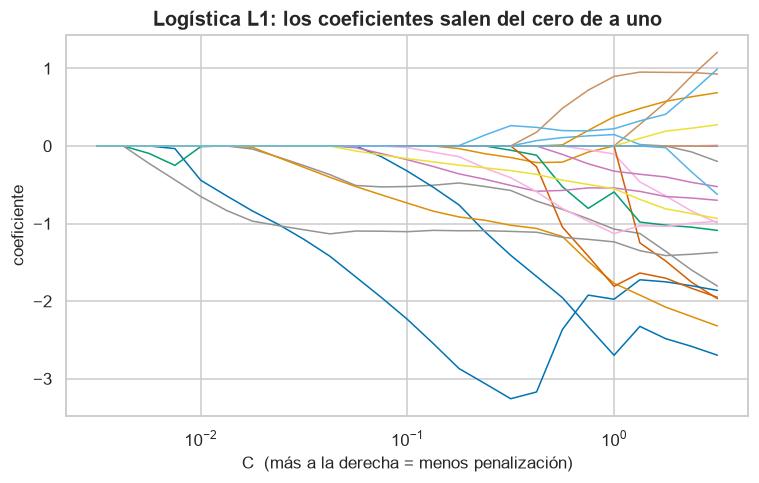

Coeficientes distintos de cero: [0, 3, 4, 8, 11, 16, 21] (cada 4 valores de C)


In [33]:
from sklearn.datasets import load_breast_cancer

Xb, yb = load_breast_cancer(return_X_y=True)
Xb = StandardScaler().fit_transform(Xb)
Cs = np.logspace(-2.5, 0.5, 25)
coefs = np.array([LogisticRegression(C=c, l1_ratio=1, solver="saga", max_iter=20_000, tol=1e-4)
                  .fit(Xb, yb).coef_.ravel() for c in Cs])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(Cs, coefs, lw=1)
ax.set_xscale("log")
ax.set(xlabel="C  (más a la derecha = menos penalización)", ylabel="coeficiente", title="Logística L1: los coeficientes salen del cero de a uno")
plt.show()
print("Coeficientes distintos de cero:", [int((np.abs(c) > 1e-8).sum()) for c in coefs[::4]], "(cada 4 valores de C)")

Es el gráfico de trayectorias de la clase 5, ahora para clasificación: con mucha penalización (izquierda) todos los coeficientes están en cero exacto, y a medida que se afloja van entrando de a uno. El conteo de abajo lo confirma: con poca $C$ el modelo usa un puñado de las 30 variables.

Usamos `solver="saga"` porque es uno de los que aceptan L1 sin penalizar el intercepto. El otro que acepta L1, `liblinear`, trata al intercepto como una variable más y **lo penaliza**, justo lo que la celda 37 dice que no hay que hacer.

### ⚠️ Confusión típica

Comparar tu implementación sin regularizar con `LogisticRegression()` así nomás. El default es `C=1.0` con L2: `sklearn` **regulariza siempre** salvo que le pidas `C=np.inf`. Los coeficientes no van a coincidir y vas a buscar un bug que no existe.

Segunda trampa: leer $C$ como $\lambda$. Van al revés: $C$ grande es **poca** penalización. Y el factor exacto depende de cómo escribe cada fuente la penalización ($\lambda\|\beta\|^2$ en la clase, $\frac{1}{2C}\|\beta\|^2$ en `sklearn`), así que antes de comparar números conviene hacer la cuenta de traducción, como hicimos arriba.

### ❓ La pregunta que quedó abierta

La celda 37 termina con *"¿Cómo se resuelve?"* y la clase se termina. Resumen de lo que desarrollamos arriba:

- **L2**: con Newton/IRLS, igual que sin penalizar, sumando $2\lambda\mathbf{I}_0$ al Hessiano. Cada iteración es una Ridge ponderada, siempre invertible, y el máximo existe aunque los datos sean separables.
- **L1**: no hay derivada en cero, así que se combina la aproximación cuadrática de IRLS con *coordinate descent* y *soft-thresholding* de la clase 5 (📕 ESL §4.4.4). También se puede atacar con métodos de optimización convexa genéricos; `sklearn` usa `saga`, una variante de descenso por gradiente estocástico que maneja el término $|\beta_j|$ con un paso de *soft-thresholding*.

## 🧵 El hilo conductor

En la clase 1 quedó establecido que, con pérdida 0-1, el mejor clasificador posible elige la clase de mayor posterior, $\arg\max_k P(G = k \mid X = x)$. El problema es que el posterior no se conoce. Toda esta clase es una respuesta a esa pregunta, con una restricción autoimpuesta: que las fronteras resultantes sean hiperplanos. Hubo tres respuestas. La regresión sobre indicadoras aproxima cada posterior con una recta, usando todo lo de las clases 2 a 5, y paga por eso: salidas que no son probabilidades y clases enteras tapadas por el masking. LDA va por el camino largo: modela cómo se generan las $x$ de cada clase (normales con la misma forma), y del supuesto de covarianza común sale, por cancelación, una frontera lineal; si se suelta ese supuesto sale QDA, con fronteras cuadráticas. La regresión logística va por el camino corto: modela directamente que el log-odds es lineal, sin decir nada de las $x$.

La parte técnica tiene su propio hilo. LDA se entrena "contando": proporciones, promedios y una covarianza agrupada, todo en forma cerrada, y la descomposición espectral lo convierte en un centroide más cercano en un espacio esferizado, de donde sale también la reducción a $K - 1$ dimensiones (y, en la práctica, esa descomposición se calcula con la SVD de los residuos, como en la clase 3). La logística, en cambio, no tiene solución cerrada: sus ecuaciones $\mathbf{X}^T(\mathbf{y} - \mathbf{p}) = 0$ son la ecuación normal de la clase 2 con la predicción lineal reemplazada por una sigmoide. Por eso apareció Newton-Raphson, y por eso cada paso de Newton termina siendo un cuadrados mínimos ponderado (IRLS). La clase 2 sigue ahí abajo, ahora dentro de un loop.

Y la regularización cerró el círculo con las clases 4 y 5. Ridge sobre la logística es una Ridge ponderada en cada iteración y rescata al método de los datos separables; Lasso sobre la logística usa el *coordinate descent* con *soft-thresholding* de la clase 5 dentro de IRLS. Lo que queda del capítulo 4 de ESL es §4.5, los **hiperplanos separadores**: en lugar de aproximar posteriores, buscar directamente un hiperplano que separe las clases, que es la puerta de entrada a las SVM (📕 ESL cap. 12). La notebook del cap. 4 de este repo ya lo desarrolla, junto con la comparación LDA vs. logística de ESL §4.4.5 que acá quedó en una línea.

## ✅ Autoevaluación

**1.** La regresión logística modela una probabilidad con una sigmoide, que no es lineal. ¿Por qué se dice que es un clasificador lineal?

<details><summary>Respuesta</summary>

Porque "lineal" se refiere a la **frontera de decisión**, no a la forma de la probabilidad. Con dos clases, se predice la clase 1 cuando $p_1 > 1/2$, lo que equivale a $p_1/(1-p_1) > 1$, lo que equivale a $\beta_0 + \beta^Tx > 0$. La frontera es $\beta_0 + \beta^Tx = 0$: un hiperplano. La sigmoide es estrictamente creciente, así que no cambia de qué lado del umbral cae cada punto; solo traduce la distancia al hiperplano en una probabilidad.

</details>

**2.** En la regresión sobre indicadoras, ¿por qué $\sum_k \hat f_k(x) = 1$ para todo $x$? ¿Eso las vuelve probabilidades?

<details><summary>Respuesta</summary>

Porque cada fila de $\mathbf{Y}$ suma 1, o sea $\mathbf{Y}\mathbf{1} = \mathbf{1}_N$, y $\mathbf{1}_N$ es la columna del intercepto en $\mathbf{X}$. Entonces $\hat{\mathbf{B}}\mathbf{1} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}e_1 = e_1$, y $(1, x^T)e_1 = 1$. No las vuelve probabilidades: sumar 1 es solo una de las dos condiciones. La otra, estar entre 0 y 1, falla, porque son rectas sin techo ni piso (en el gráfico de masking de §1 llegan a $-0.6$ y a $1.25$).

</details>

**3.** *(cuenta)* Una variable, dos clases, LDA con $\mu_1 = 0$, $\mu_2 = 2$, $\sigma^2 = 1$. ¿Dónde está la frontera si $\pi_1 = \pi_2$? ¿Y si $\pi_1 = 0.8$?

<details><summary>Respuesta</summary>

Con la ecuación recuadrada de §3 en una dimensión ($\mathbf{\Sigma}^{-1} = 1/\sigma^2 = 1$):

$$\log\frac{P(G=1 \mid x)}{P(G=2 \mid x)} = \log\frac{\pi_1}{\pi_2} - \tfrac12(\mu_1 + \mu_2)(\mu_1 - \mu_2) + x(\mu_1 - \mu_2) = \log\frac{\pi_1}{\pi_2} + 2 - 2x.$$

Con priors iguales, $\log 1 = 0$ y la frontera es $x = 1$, el punto medio. Con $\pi_1 = 0.8$, $\log(0.8/0.2) = \log 4 \approx 1.386$, y $2 - 2x + 1.386 = 0$ da $x = 1 + \frac{\log 4}{2} \approx 1.69$. La frontera se corrió **hacia la clase 2**: la clase 1, más probable a priori, gana más territorio.

</details>

**4.** *(cuenta)* Con $p = 10$ variables y $K = 3$ clases, ¿cuántos parámetros estima LDA y cuántos QDA (contando priors, medias y covarianzas)?

<details><summary>Respuesta</summary>

Priors: $K - 1 = 2$ (el tercero queda determinado porque suman 1). Medias: $K \cdot p = 30$. Una covarianza simétrica de $10 \times 10$ tiene $10 \cdot 11/2 = 55$ entradas libres. LDA estima una: $2 + 30 + 55 = 87$. QDA estima tres: $2 + 30 + 165 = 197$. Más del doble, y la diferencia crece con $p^2$. Por eso QDA necesita muchos más datos para estimar con la misma precisión, y por eso existe el punto intermedio de ESL §4.3.1.

</details>

**5.** ¿Por qué la covarianza agrupada de LDA divide por $N - K$ y no por $N - 1$ ni por $N$?

<details><summary>Respuesta</summary>

Porque cada punto se centra en la media **estimada de su clase**, y hay $K$ medias estimadas. Para cada clase, la suma de productos exteriores de los residuos tiene esperanza $(N_k - 1)\mathbf{\Sigma}$; sumando las $K$ clases da $(N - K)\mathbf{\Sigma}$. Dividir por $N - K$ hace al estimador insesgado (lo viste en la simulación de §4). $N - 1$ correspondería a una sola media global, que no es lo que se usa. $N$ es el divisor de máxima verosimilitud, sesgado hacia abajo.

</details>

**6.** ¿Qué pasa si dos clases tienen la **misma media** y distinta covarianza? ¿Qué hace LDA y qué hace QDA?

<details><summary>Respuesta</summary>

En LDA la dirección de la frontera es $\mathbf{\Sigma}^{-1}(\mu_1 - \mu_2) = 0$. El log-cociente de posteriores se reduce a la constante $\log(\pi_1/\pi_2)$: no depende de $x$, así que LDA clasifica **todo** en la clase más probable a priori. Las medias estimadas nunca son exactamente iguales, así que en la práctica sale alguna frontera, pero es ruido. QDA, en cambio, ve la diferencia de formas: el término $-\frac12 x^T(\mathbf{\Sigma}_1^{-1} - \mathbf{\Sigma}_2^{-1})x$ no se cancela, y la frontera es una elipse alrededor de la clase compacta (el gráfico de §4).

</details>

**7.** *(cuenta)* En la regresión logística binaria arrancás Newton desde $\beta = 0$. ¿Cuánto valen $\mathbf{p}$ y $\mathbf{W}$? ¿A qué problema conocido es equivalente el primer paso?

<details><summary>Respuesta</summary>

Con $\beta = 0$, $\eta_i = 0$ para todos, así que $p_i = \sigma(0) = 1/2$ y $W_{ii} = \frac12 \cdot \frac12 = \frac14$: $\mathbf{W} = \frac14\mathbf{I}$. La respuesta ajustada es $z_i = 0 + \frac{y_i - 1/2}{1/4} = 4(y_i - \frac12)$, que vale $+2$ si $y_i = 1$ y $-2$ si $y_i = 0$. El paso es $(\mathbf{X}^T\tfrac14\mathbf{X})^{-1}\mathbf{X}^T\tfrac14\mathbf{z} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{z}$: los $\frac14$ se cancelan y queda **cuadrados mínimos comunes** regresando una codificación $\pm 2$ de las etiquetas. El primer paso de la logística es la regresión sobre indicadoras de §1, con otra codificación.

</details>

**8.** ¿Qué pasa si los datos de entrenamiento son linealmente separables y corrés Newton sin regularizar? ¿Y con penalización L2?

<details><summary>Respuesta</summary>

Sin regularizar, el máximo de $\ell$ no existe: tomando el hiperplano separador y multiplicando $\beta$ por $t \to \infty$, cada $p_i$ tiende a su etiqueta y $\ell$ sube hacia 0 sin alcanzarlo. Newton persigue ese máximo inexistente: $\|\beta\|$ crece en cada iteración, los pesos $p_i(1-p_i)$ se van a 0, $\mathbf{X}^T\mathbf{W}\mathbf{X}$ se vuelve casi singular y $\mathbf{W}^{-1}$ en $\mathbf{z}$ explota numéricamente. Con L2, la función objetivo es $\ell - \lambda\|\beta\|^2$: como $\ell \le 0$ y la penalización va a $-\infty$, el máximo está a distancia finita, el Hessiano $-(\mathbf{X}^T\mathbf{W}\mathbf{X} + 2\lambda\mathbf{I}_0)$ es invertible, y Newton converge.

</details>

**9.** Si $\hat{\mathbf{\Sigma}}$ resulta diagonal, ¿esferizar es lo mismo que estandarizar las variables?

<details><summary>Respuesta</summary>

Casi, pero no necesariamente. Si $\hat{\mathbf{\Sigma}}$ es diagonal, sus autovectores son los ejes, $\mathbf{U}$ es la identidad (salvo orden y signos) y esferizar es dividir cada variable por su desvío **dentro de clase**, $\sqrt{\lambda_j}$. La estandarización común divide por el desvío **total**, que incluye la separación entre las medias de las clases. Coinciden solo si la estandarización se hace con desvíos dentro de clase; con la estandarización de siempre, las variables que mejor separan las clases quedan más achicadas que las demás.

</details>

**10.** *(V/F con cálculo)* (a) "Diagonalizar $\hat{\mathbf{\Sigma}}_k = \mathbf{U}_k\mathbf{D}_k\mathbf{U}_k^T$ hace a QDA más rápido, porque evita invertir matrices." Justificá. (b) Una clase tiene autovalores $\lambda_{k1} = 9$, $\lambda_{k2} = 1$, y un punto tiene coordenadas $z = (3, 2)$ en los ejes de su elipse. ¿Cuánto vale su distancia de Mahalanobis al cuadrado? ¿Qué coordenada pesa más?

<details><summary>Respuesta</summary>

(a) Falso como argumento de velocidad: diagonalizar una matriz de $p \times p$ cuesta del orden de $p^3$ operaciones, igual que invertirla, y en los dos casos se hace una sola vez al entrenar. Lo que se gana es: **diagnóstico**, porque los $\lambda_{kl}$ casi nulos muestran en qué dirección dividir amplifica el ruido, que es lo que arregla el dial $\gamma$ de RDA; **lectura**, porque Mahalanobis queda como $\sum_l z_l^2/\lambda_{kl}$ (cuenta desvíos sobre los ejes de la elipse) y $-\frac12\log|\hat{\mathbf{\Sigma}}_k|$ queda como menos el logaritmo del volumen de la elipse; y, de yapa, un log-determinante estable como suma de logaritmos (aunque eso también se logra sin diagonalizar, con `slogdet`).

(b) $\frac{3^2}{9} + \frac{2^2}{1} = 1 + 4 = 5$. Pesa más la segunda: sus 2 unidades son **dos** desvíos ($\sqrt1 = 1$), mientras que las 3 unidades de la primera son **uno** ($\sqrt9 = 3$). La coordenada más grande en centímetros no es la que más aleja.

</details>

## 🎯 Centros para los ejercicios

### Ejercicio 1 — Regresión lineal sobre indicadoras con tres clases

- **De qué va realmente:** reproducir el **masking** de §1 en dos dimensiones. La figura que cita el enunciado muestra tres clases alineadas donde la regresión sobre indicadoras no le asigna región a la del medio. El ejercicio es entender que eso no es mala suerte: pasa porque la indicadora de la clase del medio tiene forma de "bulto" a lo largo de la línea de los centros, y una función lineal no puede hacer un bulto.
- **Por dónde arrancar:** por los datos, que es lo que el enunciado te pide pensar. Tres nubes normales con los centros **sobre una misma recta** (por ejemplo, sobre la diagonal $x_1 = x_2$), igual dispersión, bien separadas. Después, la matriz indicadora con `np.eye(3)[g]` y el ajuste con `lstsq` sobre $\mathbf{X}$ con columna de unos, como en la segunda celda de código de §1.
- **Con qué chequear:** las filas de $(1, x^T)\hat{\mathbf{B}}$ tienen que sumar 1 en cualquier punto (§1). La clase del medio tiene que quedarse sin región, o con una región ridícula, aunque a ojo sus puntos estén perfectamente separados. Contraprueba: corré el centro del medio fuera de la recta y la región tiene que reaparecer.
- **⚠️ Dónde te vas a trabar:** al graficar las fronteras. El camino es una grilla con `np.meshgrid`, predecir en todos sus puntos y pintar con `contourf`. Dos tropiezos: olvidarte de agregarle la columna de unos a la grilla (la grilla también necesita el $(1, x^T)$), y el `ravel`/`reshape` para volver de la lista de puntos a la forma de la grilla.

### Ejercicio 2 — LDA y QDA desde cero

- **De qué va realmente:** armar el clasificador plug-in de §4: estimar $\hat\pi_k$, $\hat\mu_k$ y la covarianza (agrupada para LDA, una por clase para QDA), y clasificar con el $\arg\max$ de los $\delta_k$ de §3 y §4. Con los datos del Ejercicio 1, ver que LDA **no** sufre masking aunque también tenga fronteras lineales.
- **Por dónde arrancar:** separá estimar de predecir. Una función que recibe $\mathbf{X}$ y $g$ y devuelve $\hat\pi$ (vector de $K$), $\hat\mu$ (matriz $K \times p$) y la(s) covarianza(s). Otra que recibe esos parámetros y una matriz de puntos y devuelve una matriz $N \times K$ de $\delta_k$. Probala primero con LDA.
- **Con qué chequear:** la $\hat{\mathbf{\Sigma}}$ agrupada tiene que parecerse a la $\mathbf{\Sigma}$ con la que generaste los datos. El $\arg\max$ de tus $\delta_k$ tiene que coincidir punto a punto con el $\arg\max$ de $\log(f_k(x)\hat\pi_k)$ calculado con `scipy.stats.multivariate_normal` y tus parámetros estimados (§2), tanto para LDA como para QDA. En los datos alineados, las tres clases deben tener región con LDA.
- **⚠️ Dónde te vas a trabar:** en la covarianza agrupada. Cada punto se centra en la media de **su** clase, no en la media global, y el divisor es $N - K$ (§4). En QDA, en no olvidarte del $-\frac12\log|\hat{\mathbf{\Sigma}}_k|$. Y en vectorizar la forma cuadrática para muchos puntos a la vez: `np.einsum` como en §2, o `((D @ Sinv) * D).sum(axis=1)` con `D` la matriz de diferencias.

### Ejercicio 3 — LDA y QDA de sklearn contra la implementación propia

- **De qué va realmente:** distinguir **el modelo** de **las convenciones de implementación**. Mismo modelo puede dar números distintos según cómo se estime cada pieza, y el ejercicio es encontrar dónde difieren y si eso importa para clasificar.
- **Por dónde arrancar:** `LinearDiscriminantAnalysis(store_covariance=True)` y `QuadraticDiscriminantAnalysis(store_covariance=True)` (sin ese argumento no guardan la covarianza). Compará en este orden: predicciones sobre la grilla, después `priors_` y `means_`, y por último `covariance_` (en LDA, una matriz; en QDA, una lista con una por clase).
- **Con qué chequear:** priors y medias tienen que coincidir a la precisión de la máquina; si no, tenés un bug en la estimación. Las predicciones deberían coincidir en prácticamente toda la grilla. Para las covarianzas, si no coinciden, dividí elemento a elemento la tuya por la de `sklearn`: si da una constante, es una convención, no un error.
- **⚠️ Dónde te vas a trabar:** en las covarianzas. Revisá con qué divisor arma cada una `sklearn` (¿$N$, $N - 1$, $N - K$, $N_k - 1$?) y si usa el mismo criterio en LDA que en QDA. Después preguntate: si $\hat{\mathbf{\Sigma}}$ se multiplica por una constante, ¿cambian las fronteras? Mirá la ecuación recuadrada de §3 y fijate qué términos escalan con $\mathbf{\Sigma}^{-1}$ y cuál no.

### Ejercicio 4 — Regresión logística por Newton-Raphson

- **De qué va realmente:** implementar la iteración de §9 y ver con tus propios ojos la convergencia cuadrática de §6: en pocas iteraciones el gradiente pasa a ser del orden de la precisión de la máquina.
- **Por dónde arrancar:** $\mathbf{X}$ con columna de unos, $\beta = 0$, y escribí **un solo paso**: calcular $\mathbf{p}$, el gradiente $\mathbf{X}^T(\mathbf{y} - \mathbf{p})$, el Hessiano, y actualizar. Imprimí $\ell$ antes y después. Recién cuando un paso haga subir $\ell$, metelo en un loop con un criterio de parada.
- **Con qué chequear:** $\ell$ tiene que **subir** en cada iteración; la norma del gradiente tiene que caer muy rápido; al final, $\sum_i \hat p_i = \sum_i y_i$ (§8). Para los coeficientes, compará contra `statsmodels` (`sm.GLM(..., family=sm.families.Binomial())`, que guarda la historia de iteraciones, §9) o contra `LogisticRegression(C=np.inf)`.
- **⚠️ Dónde te vas a trabar:** en la comparación con `sklearn`. Por defecto **regulariza** (`C=1.0`, §10), así que sin `C=np.inf` tus coeficientes no van a coincidir y vas a buscar un bug que no existe. Segundo tropiezo: el signo del paso (§9). Tercero: si generás las dos clases muy separadas, quedan **separables** y Newton diverge (§9): eso no es un bug tuyo, es que el máximo no existe. Generá clases que se solapen, o usá el mecanismo de §8 (etiquetas sorteadas con la sigmoide de un $\beta$ que elijas).